# SMC Strategy Walkthrough — Visual Step-by-Step

Demonstrates each filter stage of the strategy on real SNDK data.

| Step | Function | Description |
|------|----------|-------------|
| 1 | `find_swings` | Detect HTF swing highs / lows |
| 2 | `detect_bos_choch` | Identify BOS / CHoCH structure breaks |
| 3 | `determine_trend` | Classify trend direction from BOS sequence |
| 4 | `detect_fvg` | Find Fair Value Gaps |
| 5 | `fvg_entry_depth` | Wick penetration depth into FVG |
| 6 | `check_ltf_confirmation` | LTF CHoCH + BOS entry confirmation |
| 7 | Trade setup | SL / TP construction, RR filter |
| 8 | SL sweep | `sl_buffer_pct` x `max_sl_pct` sensitivity |
| 9 | Swing sweep | `swing_lookback` x `bos_count` sensitivity |
| 10 | Displacement sweep | FVG quality filter sensitivity |
| 11 | `kd_trend` | KD channel momentum trend detector |

---

**Colour conventions**

| Colour | Meaning |
|--------|---------|
| Green | Bull candle / bull signal / bull structure |
| Red | Bear candle / bear signal / bear structure |
| Cyan | Entry confirmation / LTF signal |
| Gold | Annotation (FVG zone, SL/TP, parameter labels) |


In [2]:
%run ../nb_setup.py


Project root : e:\project\moomoo
matplotlib   : 3.10.9  backend=module://matplotlib_inline.backend_inline
Setup complete


## Data Loading


In [3]:
import itertools, sys

# Purge stale project modules so each kernel run starts clean.
_PROJECT_PKGS = ('strategy', 'backtest', 'feeds', 'core', 'analysis')
_stale = [k for k in list(sys.modules) if k.split('.')[0] in _PROJECT_PKGS]
for _m in _stale:
    del sys.modules[_m]
if _stale:
    print('Cleared', len(_stale), 'stale module(s)')

from feeds.fetcher import fetch_klines
from strategy.smc import (
    find_swings, detect_bos_choch, detect_fvg,
    determine_trend, fvg_entry_depth,
    check_ltf_confirmation, is_displacement_candle,
)
from strategy.smc.kd_trend import compute_kd, kd_trend
from core.draw import draw_bos_choch, draw_fvg
from backtest.engine import BacktestParams, run_backtest

import pandas as pd

_DISP_MULT  = 1.5
_BODY_RATIO = 0.5

CODE, START, END = 'US.SNDK', '2025-02-13', '2025-12-31'
htf_raw = fetch_klines(CODE, '60m', START, END)
ltf_raw = fetch_klines(CODE, '15m', START, END)

print('HTF 60m :', len(htf_raw), 'bars ', htf_raw['time_key'].iloc[0], '->', htf_raw['time_key'].iloc[-1])
print('LTF 15m :', len(ltf_raw), 'bars ', ltf_raw['time_key'].iloc[0], '->', ltf_raw['time_key'].iloc[-1])

params = BacktestParams(trend_tf='60m', entry_tf='15m',
                        swing_lookback=2, bos_count=1,
                        fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.20,
                        sl_buffer_pct=0.001, max_sl_pct=0.010, min_rr=1.5)
result = run_backtest(htf_raw, ltf_raw, params)

s = result.summary_dict()
print('Backtest:', s['n_trades'], 'trades  WR=' + str(round(s['win_rate']*100)) + '%  TotalR=' + str(round(s['total_r'],2)) + '  PF=' + str(round(s['profit_factor'],2)))
for i, t in enumerate(result.trades):
    print(f'  #{i+1} {t.direction}  entry={t.entry_time}  SL={t.sl:.2f}  TP={t.tp:.2f}  RR={t.planned_rr:.2f}  R={t.r_multiple:+.2f}  [{t.result}]')


[fetcher] Cache hit: US.SNDK 60m  (1545 bars)
[fetcher] Cache hit: US.SNDK 15m  (5736 bars)
HTF 60m : 1545 bars  2025-02-13 10:30:00 -> 2025-12-31 16:00:00
LTF 15m : 5736 bars  2025-02-13 09:45:00 -> 2025-12-31 16:00:00
Backtest: 3 trades  WR=67%  TotalR=11.6  PF=12.6
  #1 bear  entry=2025-06-02 15:15:00  SL=37.73  TP=37.05  RR=8.25  R=+8.25  [win]
  #2 bull  entry=2025-06-05 10:45:00  SL=38.59  TP=40.00  RR=4.34  R=+4.34  [win]
  #3 bull  entry=2025-07-07 15:00:00  SL=45.49  TP=46.59  RR=2.16  R=-1.00  [loss]


## Strategy Architecture


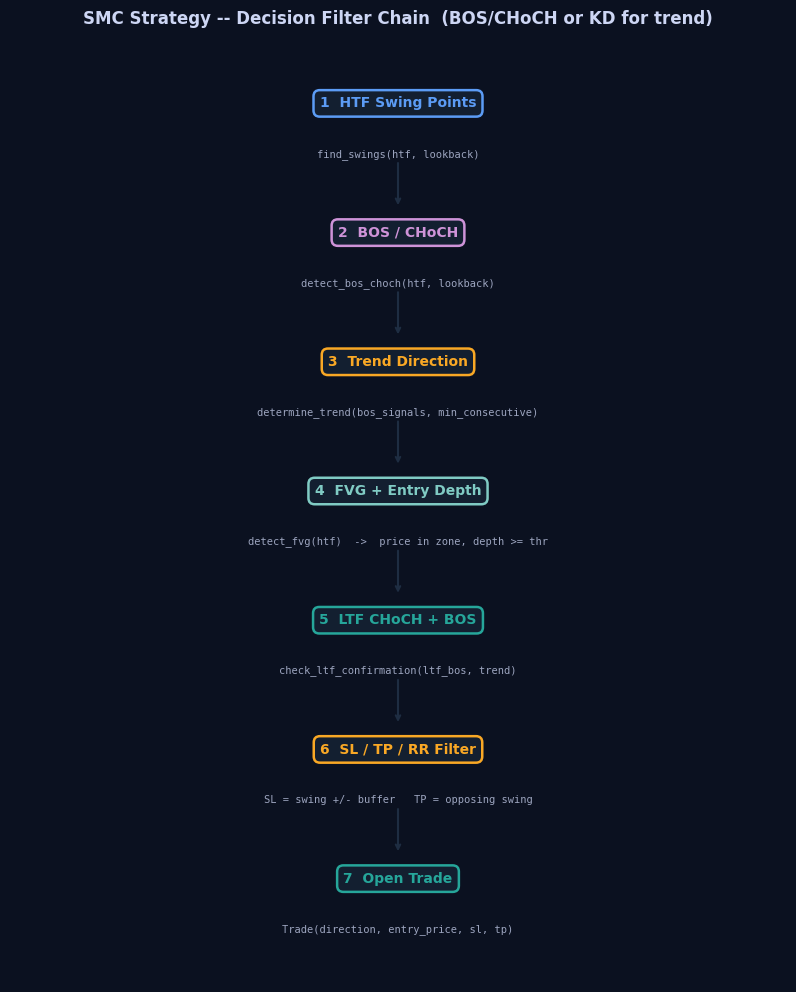

In [4]:
fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
ax.set_facecolor(BG); ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(-0.5, 14.5)

_steps = [
    ('1  HTF Swing Points',    'find_swings(htf, lookback)',                          BLUE),
    ('2  BOS / CHoCH',         'detect_bos_choch(htf, lookback)',                    PURPLE),
    ('3  Trend Direction',     'determine_trend(bos_signals, min_consecutive)',       GOLD),
    ('4  FVG + Entry Depth',   'detect_fvg(htf)  ->  price in zone, depth >= thr',  CYAN),
    ('5  LTF CHoCH + BOS',     'check_ltf_confirmation(ltf_bos, trend)',             GREEN),
    ('6  SL / TP / RR Filter', 'SL = swing +/- buffer   TP = opposing swing',        GOLD),
    ('7  Open Trade',          'Trade(direction, entry_price, sl, tp)',              GREEN),
    ('—  Alt: KD Trend',       'kd_trend(htf, fast, slow, window)  ->  bull/bear/None', GOLD),
]
ys = [13, 11, 9, 7, 5, 3, 1]
for y, (title, code, color) in zip(ys, _steps):
    ax.text(5, y + 0.1, title, color=color, fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.45', fc=BG2, ec=color, lw=1.8))
    ax.text(5, y - 0.6, code, color=FG, fontsize=7.5, ha='center', va='top',
            alpha=0.75, fontfamily='monospace')
for ya, yb in zip(ys[:-1], ys[1:]):
    ax.annotate('', xy=(5, yb + 0.48), xytext=(5, ya - 0.78),
                arrowprops=dict(arrowstyle='->', color=GRID, lw=1.5))

ax.set_title('SMC Strategy -- Decision Filter Chain  (BOS/CHoCH or KD for trend)', color=FG, fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## Step 1 — HTF Swing Points (`find_swings`)

Bar `i` is a swing high if its high is the highest within `lookback` bars on each side.
Swing points are forced to alternate (high -> low -> high ...).

`lookback` larger -> fewer, smoother swings; smaller -> more signals, more noise.


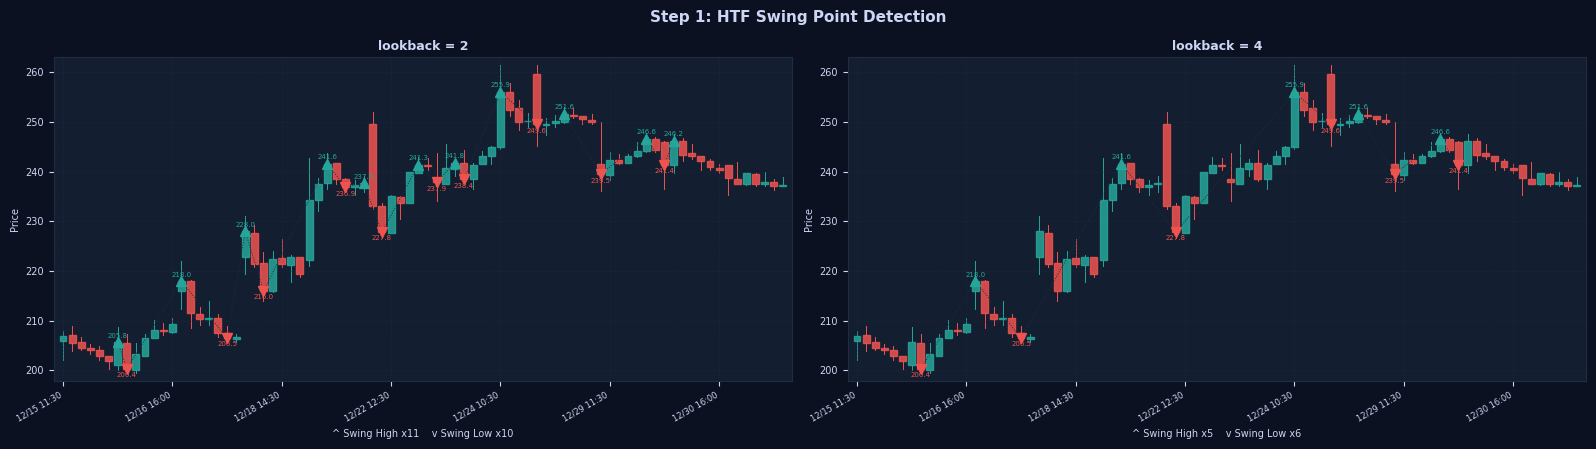

In [5]:
htf = htf_raw.tail(80).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)
for ax, lb in zip(axes, [2, 4]):
    swings = find_swings(htf, lookback=lb)
    draw_candles(ax, htf)
    style_ax(ax, f'lookback = {lb}')
    time_ticks(ax, htf, step=12)

    for sw in swings:
        if sw['kind'] == 'high':
            ax.plot(sw['idx'], sw['price'], '^', color=GREEN, ms=7, zorder=5)
            ax.text(sw['idx'], sw['price'] * 1.003, f"{sw['price']:.1f}",
                    color=GREEN, fontsize=5, ha='center', va='bottom')
        else:
            ax.plot(sw['idx'], sw['price'], 'v', color=RED, ms=7, zorder=5)
            ax.text(sw['idx'], sw['price'] * 0.997, f"{sw['price']:.1f}",
                    color=RED, fontsize=5, ha='center', va='top')

    xs = [s['idx'] for s in swings]
    ys = [s['price'] for s in swings]
    ax.plot(xs, ys, color=GRID, lw=0.7, ls=':', zorder=3)

    nh = sum(1 for s in swings if s['kind'] == 'high')
    nl = sum(1 for s in swings if s['kind'] == 'low')
    ax.set_xlabel(f'^ Swing High x{nh}    v Swing Low x{nl}', fontsize=7)
    ax.set_ylabel('Price', fontsize=7)

plt.suptitle('Step 1: HTF Swing Point Detection', color=FG, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 2 — BOS / CHoCH (`detect_bos_choch`)

| Signal | Condition | Meaning |
|--------|-----------|--------|
| **BOS up** | Breaks above prior swing high (trend continuation) | Structure extends |
| **BOS down** | Breaks below prior swing low (trend continuation) | Structure extends |
| **CHoCH up** | Breaks prior high during downtrend | Reversal -> bull |
| **CHoCH down** | Breaks prior low during uptrend | Reversal -> bear |

Solid line = BOS, dashed line = CHoCH.


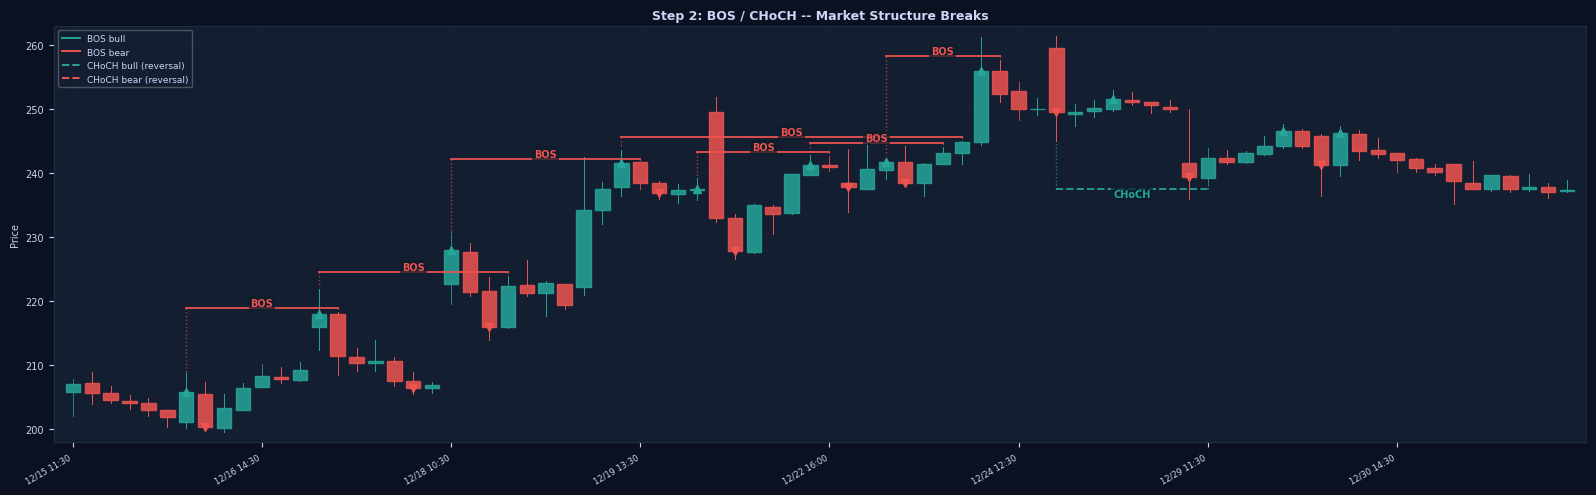

In [6]:
swings  = find_swings(htf, lookback=2)
signals = detect_bos_choch(htf, lookback=2)

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
style_ax(ax, 'Step 2: BOS / CHoCH -- Market Structure Breaks')
time_ticks(ax, htf, step=10)

for sw in swings:
    m = '^' if sw['kind'] == 'high' else 'v'
    c = GREEN if sw['kind'] == 'high' else RED
    ax.plot(sw['idx'], sw['price'], m, color=c, ms=6, zorder=5)

draw_bos_choch(ax, htf, signals)

items = [
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='-',  label='BOS bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='-',  label='BOS bear'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='--', label='CHoCH bull (reversal)'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='--', label='CHoCH bear (reversal)'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 3 — Trend Direction (`determine_trend`)

Walk the BOS/CHoCH sequence:
- **CHoCH** -> reset direction, reset consecutive count to 1
- Same-direction **BOS** -> count +1
- Count >= `min_consecutive` before declaring a valid trend

Background: green = bull zone, red = bear zone, grey = no confirmed trend.


{"idx":>5}  {"type":>6}  {"dir":>5}  {"price":>8}   min=1      min=2
----------------------------------------------------------
   14     BOS   bull    208.80           -          -
   23     BOS   bull    221.99           -          -
   30     BOS   bull    231.00           -          -
   40     BOS   bull    239.20           -          -
   46     BOS   bull    242.86           -          -
   47     BOS   bull    243.71           -          -
   49     BOS   bull    242.47           -          -
   60   CHoCH   bear    245.10        bear          -


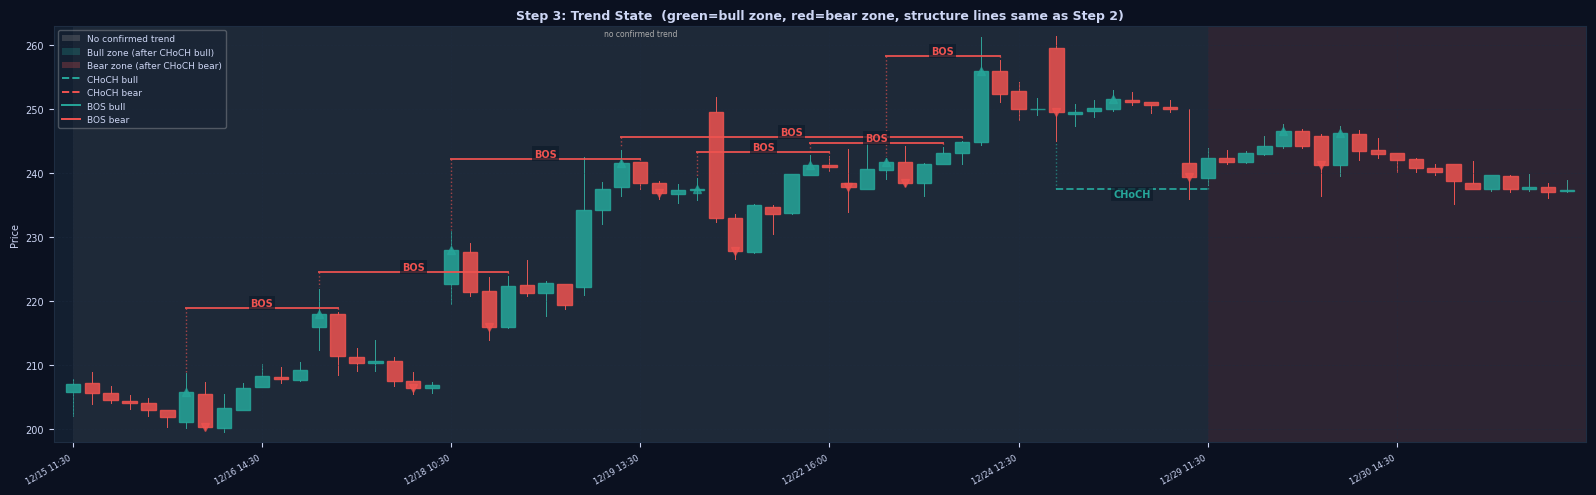

In [7]:
print(f'{{"idx":>5}}  {{"type":>6}}  {{"dir":>5}}  {{"price":>8}}   min=1      min=2')
print('-' * 58)
t1 = t2 = None; c1 = c2 = 0
for sig in sorted(signals, key=lambda s: s['idx']):
    if sig['type'] == 'CHoCH':
        t1 = t2 = sig['direction']; c1 = c2 = 1
    elif sig['type'] == 'BOS':
        if sig['direction'] == t1: c1 += 1
        if sig['direction'] == t2: c2 += 1
    o1 = (t1 or '-') if (t1 and c1 >= 1) else '-'
    o2 = (t2 or '-') if (t2 and c2 >= 2) else '-'
    print(f"{sig['idx']:>5}  {sig['type']:>6}  {sig['direction']:>5}  "
          f"{sig['price']:>8.2f}   {o1:>9}  {o2:>9}")

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
style_ax(ax, 'Step 3: Trend State  (green=bull zone, red=bear zone, structure lines same as Step 2)')
time_ticks(ax, htf, step=10)

# Background trend zones
_sigs_sorted = sorted(signals, key=lambda s: s['idx'])
_first_choch = next((s['idx'] for s in _sigs_sorted if s['type'] == 'CHoCH'), None)
if _first_choch:
    ax.axvspan(0, _first_choch, facecolor='#888888', alpha=0.10)
    ax.text(_first_choch / 2, ax.get_ylim()[1] * 0.998,
            'no confirmed trend', color='#aaaaaa', fontsize=5.5, ha='center', va='top')

cur = None; prev_x = 0
for sig in _sigs_sorted:
    if cur is not None:
        ax.axvspan(prev_x, sig['idx'],
                   facecolor=GREEN if cur == 'bull' else RED, alpha=0.12)
    if sig['type'] == 'CHoCH':
        cur = sig['direction']
    prev_x = sig['idx']
if cur:
    ax.axvspan(prev_x, len(htf),
               facecolor=GREEN if cur == 'bull' else RED, alpha=0.12)

# Swing point markers
swings_htf = find_swings(htf, lookback=2)
for sw in swings_htf:
    m = '^' if sw['kind'] == 'high' else 'v'
    c = GREEN if sw['kind'] == 'high' else RED
    ax.plot(sw['idx'], sw['price'], m, color=c, ms=6, zorder=5, alpha=0.7)

# BOS / CHoCH structure lines (trade_viewer style)
draw_bos_choch(ax, htf, signals)

items = [
    mpatches.Patch(fc='#888888', alpha=0.3,  label='No confirmed trend'),
    mpatches.Patch(fc=GREEN,     alpha=0.25, label='Bull zone (after CHoCH bull)'),
    mpatches.Patch(fc=RED,       alpha=0.25, label='Bear zone (after CHoCH bear)'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='--', label='CHoCH bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='--', label='CHoCH bear'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='-',  label='BOS bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='-',  label='BOS bear'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 4 — Fair Value Gap (`detect_fvg`)

**Three-candle pattern:**
- **Bull FVG**: `high[i-2] < low[i]` -- upward gap left by the middle candle -> green zone
- **Bear FVG**: `low[i-2] > high[i]` -- downward gap left by the middle candle -> red zone

Price pulling back into the FVG triggers the entry sequence (core SMC logic).
Faded = filled by a later candle (invalidated); saturated = still active.


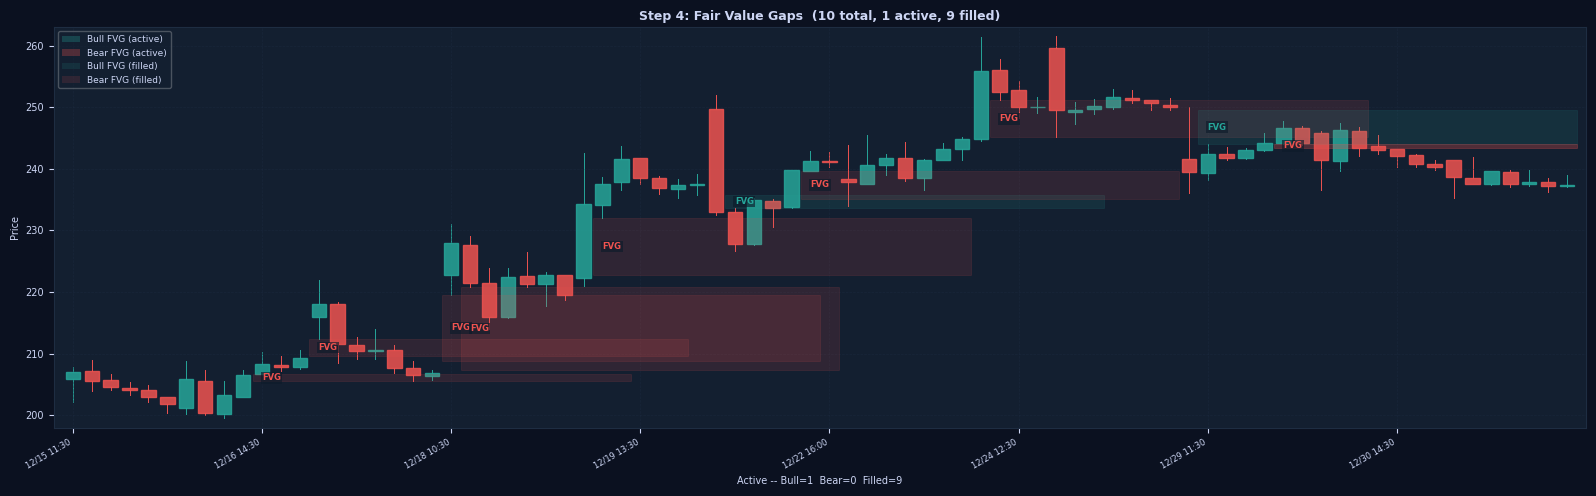

In [8]:
fvgs = detect_fvg(htf, min_gap_pct=0.002)

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
n_active = sum(1 for f in fvgs if not f['filled'])
style_ax(ax, f'Step 4: Fair Value Gaps  ({len(fvgs)} total, {n_active} active, {len(fvgs)-n_active} filled)')
time_ticks(ax, htf, step=10)

draw_fvg(ax, htf, fvgs)

n_bull   = sum(1 for f in fvgs if f['direction'] == 'bull' and not f['filled'])
n_bear   = sum(1 for f in fvgs if f['direction'] == 'bear' and not f['filled'])
n_filled = sum(1 for f in fvgs if f['filled'])
ax.set_xlabel(f'Active -- Bull={n_bull}  Bear={n_bear}  Filled={n_filled}', fontsize=7)

items = [
    mpatches.Patch(fc=GREEN, alpha=0.28, label='Bull FVG (active)'),
    mpatches.Patch(fc=RED,   alpha=0.28, label='Bear FVG (active)'),
    mpatches.Patch(fc=GREEN, alpha=0.13, label='Bull FVG (filled)'),
    mpatches.Patch(fc=RED,   alpha=0.13, label='Bear FVG (filled)'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 5 — FVG Entry Depth (`fvg_entry_depth`)

Entry is triggered by the **wick**, not the close:

- **Bull FVG**: use `bar_low` (lower wick), `depth = (top - low) / size`
- **Bear FVG**: use `bar_high` (upper wick), `depth = (high - bottom) / size`

`depth=0` just touches the edge; `depth=1` wick fully penetrates (clamped to 1.0).  
`fvg_entry_depth_pct=0.20` requires at least 20% penetration.


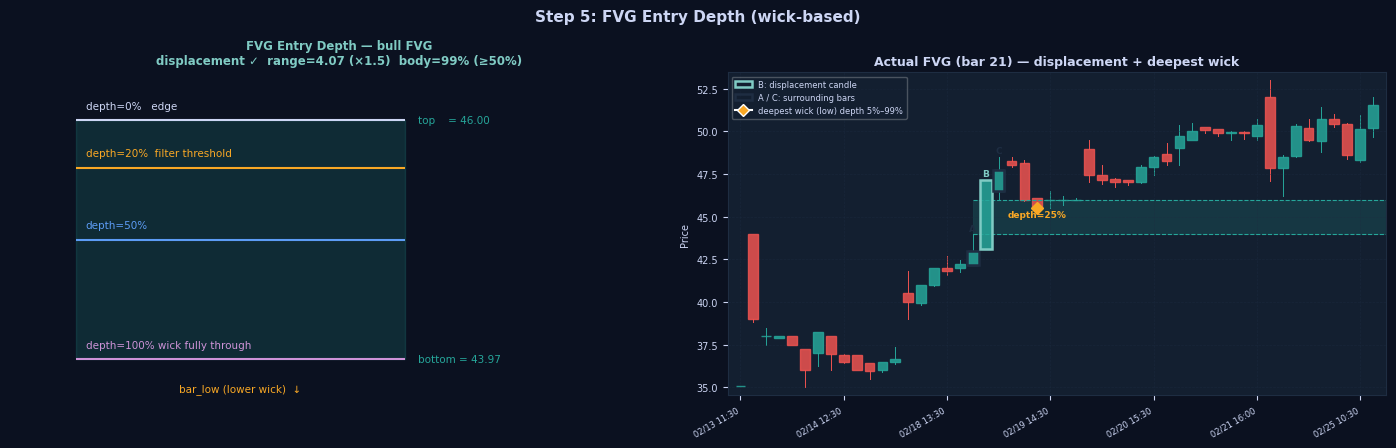

FVG bar 21: bottom=43.970  top=46.000  size=2.0300  dir=bull
Middle candle: range=4.070  body=4.040  body_ratio=0.99  displacement=True
Deepest wick : bar 24  low=45.500  depth=0.25

Depth reference table:
  depth=0.0  low=46.000  -> fvg_entry_depth=0.00
  depth=0.2  low=45.594  -> fvg_entry_depth=0.20
  depth=0.5  low=44.985  -> fvg_entry_depth=0.50
  depth=1.0  low=43.970  -> fvg_entry_depth=1.00


In [9]:
_DISP_MULT  = 1.5   # range multiplier — matches BacktestParams.displacement_atr_mult
_BODY_RATIO = 0.5   # body/range minimum — matches BacktestParams.displacement_body_ratio
_MIN_DEPTH = 0.05  # wick must enter at least this far into the FVG
_MAX_DEPTH = 0.99  # exclude full-penetration (depth=100%) from demo
_WARMUP    = 20    # skip first N bars — dataset edge may have incomplete data

# Search htf_raw for a displacement FVG with a qualifying wick entry.
htf_demo = htf_raw.reset_index(drop=True)
all_fvgs  = detect_fvg(htf_demo, min_gap_pct=0.002)

demo = None
for f in all_fvgs:
    if f['idx'] < _WARMUP:          # skip dataset warmup region
        continue
    if not is_displacement_candle(htf_demo, f['idx'], _DISP_MULT, _BODY_RATIO):
        continue
    _idx, _bot, _top = f['idx'], f['bottom'], f['top']
    _bull = f['direction'] == 'bull'
    for j in range(_idx + 1, min(len(htf_demo), _idx + 30)):
        r   = htf_demo.iloc[j]
        wp  = r['low'] if _bull else r['high']
        ov  = (_bull and wp <= _top and r['high'] >= _bot) or \
              (not _bull and wp >= _bot and r['low'] <= _top)
        if ov and _MIN_DEPTH <= fvg_entry_depth(f, wp) <= _MAX_DEPTH:
            demo = f
            break
    if demo is not None:
        break

# Final fallback: first unfilled FVG in the 80-bar window
if demo is None:
    demo = next((f for f in detect_fvg(htf, min_gap_pct=0.002) if not f['filled']), None)
    htf_demo = htf

if demo is None:
    print('No FVG available for demo')
else:
    bot, top = demo['bottom'], demo['top']
    size = top - bot
    bull = demo['direction'] == 'bull'
    wick_col = 'low' if bull else 'high'
    idx  = demo['idx']

    mid_bar   = htf_demo.iloc[idx - 1]
    mid_range = mid_bar['high'] - mid_bar['low']
    mid_body  = abs(mid_bar['close'] - mid_bar['open'])
    body_ratio = mid_body / mid_range if mid_range > 0 else 0.0
    is_disp   = is_displacement_candle(htf_demo, idx, _DISP_MULT, _BODY_RATIO)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor=BG)

    # ── Left: schematic ───────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(BG2); ax.set_xlim(0, 10); ax.set_ylim(-0.15, 1.20); ax.axis('off')
    color = GREEN if bull else RED
    ax.add_patch(mpatches.Rectangle((1, 0), 5, 1, fc=color, ec=color, alpha=0.18, zorder=1))
    ax.hlines([0, 1], 1, 6, colors=color, lw=1.4, ls='--', zorder=2)
    ax.text(6.2, 0, f'bottom = {bot:.2f}', color=color, fontsize=7.5, va='center')
    ax.text(6.2, 1, f'top    = {top:.2f}', color=color, fontsize=7.5, va='center')
    for d, c, lbl in [(0.0, FG, 'depth=0%   edge'), (0.2, GOLD, 'depth=20%  filter threshold'),
                      (0.5, BLUE, 'depth=50%'), (1.0, PURPLE, 'depth=100% wick fully through')]:
        y_norm = (1 - d) if bull else d
        ax.hlines(y_norm, 1, 6, colors=c, lw=1.5, zorder=3)
        ax.text(1.15, y_norm + 0.04, lbl, color=c, fontsize=7.5, va='bottom')
    wick_lbl = 'bar_low (lower wick)  ↓' if bull else 'bar_high (upper wick)  ↑'
    ax.text(3.5, -0.10, wick_lbl, color=GOLD, fontsize=7.5, ha='center', va='top')

    disp_tag = (
        f'displacement ✓  range={mid_range:.2f} (×{_DISP_MULT})  '
        f'body={body_ratio:.0%} (≥{_BODY_RATIO:.0%})'
        if is_disp else
        f'displacement ✗  range={mid_range:.2f}  body={body_ratio:.0%}'
    )
    ax.set_title(f'FVG Entry Depth — {demo["direction"]} FVG\n{disp_tag}',
                 color=CYAN if is_disp else RED, fontsize=8.5, fontweight='bold', pad=6)

    # ── Right: 3-bar pattern + deepest wick ──────────────────────────────
    ax2 = axes[1]
    ws  = max(0, idx - 20)
    we  = min(len(htf_demo), idx + 30)
    win = htf_demo.iloc[ws:we].reset_index(drop=True)
    draw_candles(ax2, win, x0=ws)
    style_ax(ax2, f'Actual FVG (bar {idx}) — displacement + deepest wick')
    time_ticks(ax2, win, step=8, x0=ws)
    ax2.add_patch(mpatches.Rectangle(
        (idx - 2, bot), len(htf_demo) - (idx - 2), size,
        fc=color, ec=color, alpha=0.18, lw=0.5))
    ax2.hlines([bot, top], idx - 2, ws + len(win), colors=color, lw=0.8, ls='--')

    # Highlight the 3-bar FVG pattern (A, B=displacement, C)
    for bar_abs, lbl_txt, ec_col in [(idx-2,'A',GRID),(idx-1,'B',CYAN),(idx,'C',GRID)]:
        bar_j = bar_abs - ws
        if 0 <= bar_j < len(win):
            r  = win.iloc[bar_j]
            lo = min(r['open'], r['close'])
            hi = max(r['open'], r['close'])
            ax2.add_patch(mpatches.Rectangle(
                (bar_abs - 0.45, lo), 0.90, max(hi - lo, 1e-6),
                fill=False, ec=ec_col, lw=1.8, zorder=7))
            ax2.text(bar_abs, r['high'] * 1.002, lbl_txt,
                     color=ec_col, fontsize=6.5, ha='center', va='bottom', fontweight='bold')

    # Deepest qualifying wick after FVG formation
    fvg_j = idx - ws
    best_j, best_depth, best_wick = -1, -1.0, None
    for j in range(fvg_j + 1, len(win)):
        row = win.iloc[j]
        wick_price = row['low'] if bull else row['high']
        overlaps = (bull     and wick_price <= top and row['high'] >= bot) or \
                   (not bull and wick_price >= bot and row['low']  <= top)
        if overlaps:
            d = fvg_entry_depth(demo, wick_price)
            if _MIN_DEPTH <= d <= _MAX_DEPTH and d > best_depth:
                best_j, best_depth, best_wick = j, d, wick_price

    if best_j >= 0:
        xb = ws + best_j
        ax2.plot(xb, best_wick, 'D', color=GOLD, ms=6, zorder=8)
        va  = 'top' if bull else 'bottom'
        off = best_wick * (0.997 if bull else 1.003)
        ax2.text(xb, off, f'depth={best_depth:.0%}',
                 color=GOLD, fontsize=6.5, ha='center', va=va, fontweight='bold')

    ax2.set_ylabel('Price', fontsize=7)
    legend_items = [
        mpatches.Patch(fc='none', ec=CYAN, lw=1.8, label='B: displacement candle'),
        mpatches.Patch(fc='none', ec=GRID, lw=1.8, label='A / C: surrounding bars'),
        matplotlib.lines.Line2D([0], [0], marker='D', color='w', markerfacecolor=GOLD,
                                ms=6, label=f'deepest wick ({wick_col}) depth {_MIN_DEPTH:.0%}–{_MAX_DEPTH:.0%}'),
    ]
    leg = ax2.legend(handles=legend_items, fontsize=6, framealpha=0.3, labelcolor=FG, loc='upper left')
    leg.get_frame().set_facecolor(BG2)

    plt.suptitle('Step 5: FVG Entry Depth (wick-based)', color=FG, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'FVG bar {idx}: bottom={bot:.3f}  top={top:.3f}  size={size:.4f}  dir={demo["direction"]}')
    print(f'Middle candle: range={mid_range:.3f}  body={mid_body:.3f}  body_ratio={body_ratio:.2f}  displacement={is_disp}')
    if best_j >= 0:
        print(f'Deepest wick : bar {ws+best_j}  {wick_col}={best_wick:.3f}  depth={best_depth:.2f}')
    else:
        print('No qualifying wick entry found in window')
    print('\nDepth reference table:')
    for d in [0.0, 0.2, 0.5, 1.0]:
        p = (top - d * size) if bull else (bot + d * size)
        print(f'  depth={d:.1f}  {wick_col}={p:.3f}  -> fvg_entry_depth={fvg_entry_depth(demo, p):.2f}')


## Step 6 — Entry Depth x Confirmation Mode

| Mode | Logic | Parameter |
|------|-------|----------|
| `CHoCH+BOS` | Wait for LTF structure reversal after wick enters FVG | `require_ltf_confirmation=True` |
| `depth-only` | Enter as soon as wick penetrates to required depth | `require_ltf_confirmation=False` |

Sweeps `fvg_entry_depth_pct` in [5%, 10%, 20%, 30%, 50%, 70%] x both modes.


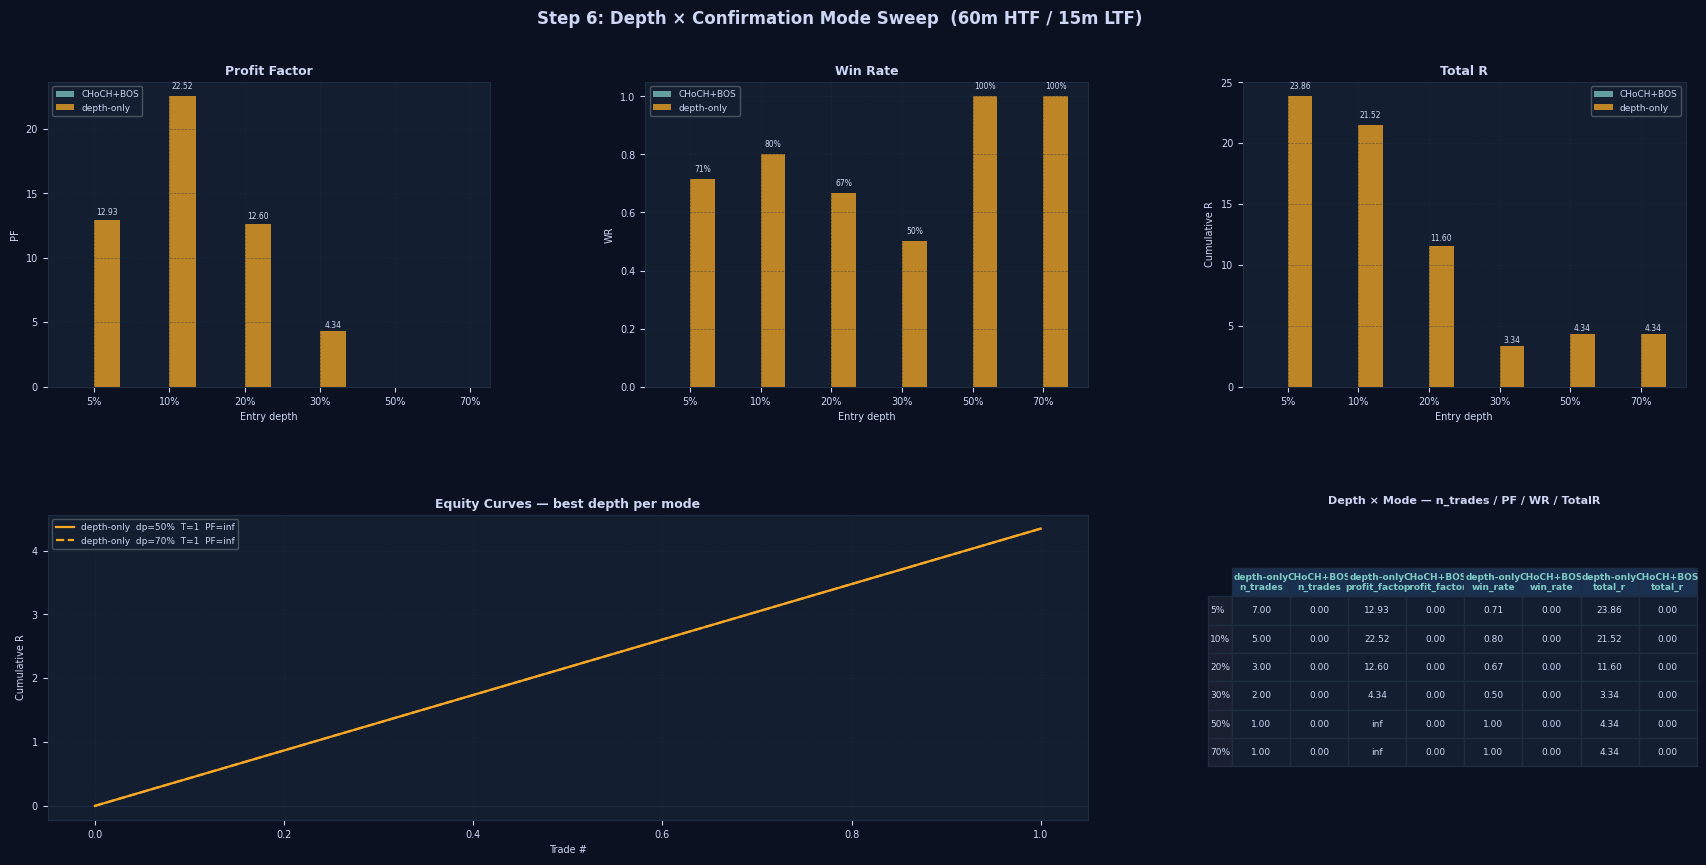

 depth  conf  n_trades  win_rate   total_r  profit_factor  max_dd    avg_r
  0.05  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.10  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.20  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.30  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.50  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.70  True         0  0.000000  0.000000       0.000000     0.0 0.000000
  0.05 False         7  0.714286 23.859134      12.929567     1.0 3.408448
  0.10 False         5  0.800000 21.523330      22.523330     1.0 4.304666
  0.20 False         3  0.666667 11.597439      12.597439     1.0 3.865813
  0.30 False         2  0.500000  3.343208       4.343208     1.0 1.671604
  0.50 False         1  1.000000  4.343208            inf     0.0 4.343208
  0.70 False         1  1.000000  4.343208            inf     0.0 4.343208


In [10]:
DEPTHS     = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70]
CONF_MODES = [True, False]
BASE = dict(trend_tf="60m", entry_tf="15m",
            swing_lookback=2, bos_count=1,
            fvg_min_width_pct=0.002,
            sl_buffer_pct=0.001, max_sl_pct=0.010, min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
records   = []
trade_map = {}
for conf, depth in itertools.product(CONF_MODES, DEPTHS):
    p = BacktestParams(**BASE, fvg_entry_depth_pct=depth,
                       require_ltf_confirmation=conf)
    r = run_backtest(htf_raw, ltf_raw, p)
    records.append(dict(
        depth=depth, conf=conf,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r, avg_r=r.avg_r,
    ))
    trade_map[(depth, conf)] = [t.r_multiple for t in r.trades]

df_sweep = pd.DataFrame(records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_wr  = fig.add_subplot(gs[0, 1])
ax_tr  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

CONF_COLOR = {True: CYAN, False: GOLD}
CONF_LABEL = {True: "CHoCH+BOS", False: "depth-only"}
bar_w = 0.35
x     = np.arange(len(DEPTHS))

def _vals(conf, col):
    return [df_sweep.loc[(df_sweep.conf == conf) & (df_sweep.depth == d), col].values[0]
            for d in DEPTHS]

for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_wr, "win_rate",      "Win Rate",      "WR"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
]:
    style_ax(ax, title)
    for conf, offset in [(True, -bar_w / 2), (False, bar_w / 2)]:
        vals = _vals(conf, col)
        bars = ax.bar(x + offset, vals, width=bar_w,
                      color=CONF_COLOR[conf], alpha=0.75,
                      label=CONF_LABEL[conf])
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.02),
                        f"{v:.2f}" if col != "win_rate" else f"{v:.0%}",
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d:.0%}" for d in DEPTHS], fontsize=7)
    ax.set_xlabel("Entry depth", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

style_ax(ax_eq, "Equity Curves — best depth per mode")
ax_eq.axhline(0, color=GRID, lw=0.8)
for conf in CONF_MODES:
    sub = df_sweep[df_sweep.conf == conf].copy()
    sub = sub[sub.n_trades > 0].sort_values("profit_factor", ascending=False)
    for rank, (_, row) in enumerate(sub.head(2).iterrows()):
        rs = trade_map[(row.depth, conf)]
        if not rs:
            continue
        eq  = np.concatenate([[0], np.cumsum(rs)])
        lbl = (f"{CONF_LABEL[conf]}  dp={row.depth:.0%}  "
               f"T={row.n_trades}  PF={row.profit_factor:.2f}")
        ax_eq.plot(eq, color=CONF_COLOR[conf], lw=1.6,
                   ls="-" if rank == 0 else "--", label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot = df_sweep.pivot(index="depth", columns="conf",
                       values=["n_trades", "profit_factor", "win_rate", "total_r"])
pivot.columns = [f"{CONF_LABEL[c]}\n{m}" for m, c in pivot.columns]
pivot.index   = [f"{d:.0%}" for d in pivot.index]
_rows = [[f"{v:.2f}" if isinstance(v, float) else str(int(v))
          for v in row] for row in pivot.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=list(pivot.index),
                   colLabels=list(pivot.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(6.5)
tbl.scale(1.05, 1.7)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        cell.set_facecolor(BG2)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Depth × Mode — n_trades / PF / WR / TotalR",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 6: Depth × Confirmation Mode Sweep  (60m HTF / 15m LTF)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_sweep.to_string(index=False))


## Step 7 — Full Trade Setup

| Component | Bull | Bear |
|-----------|------|------|
| **Entry** | LTF BOS confirmation candle close | same |
| **SL** | Nearest HTF swing low x (1 - buffer) | Nearest HTF swing high x (1 + buffer) |
| **TP** | Nearest HTF swing high (lowest available) | Nearest HTF swing low (highest available) |
| **Filter** | SL% <= max_sl_pct and RR >= min_rr | same |


Trade: bear  entry_time=2025-06-02 15:15:00
  entry=37.655  SL=37.728  TP=37.055
  RR=8.25  Result=win  R=+8.25


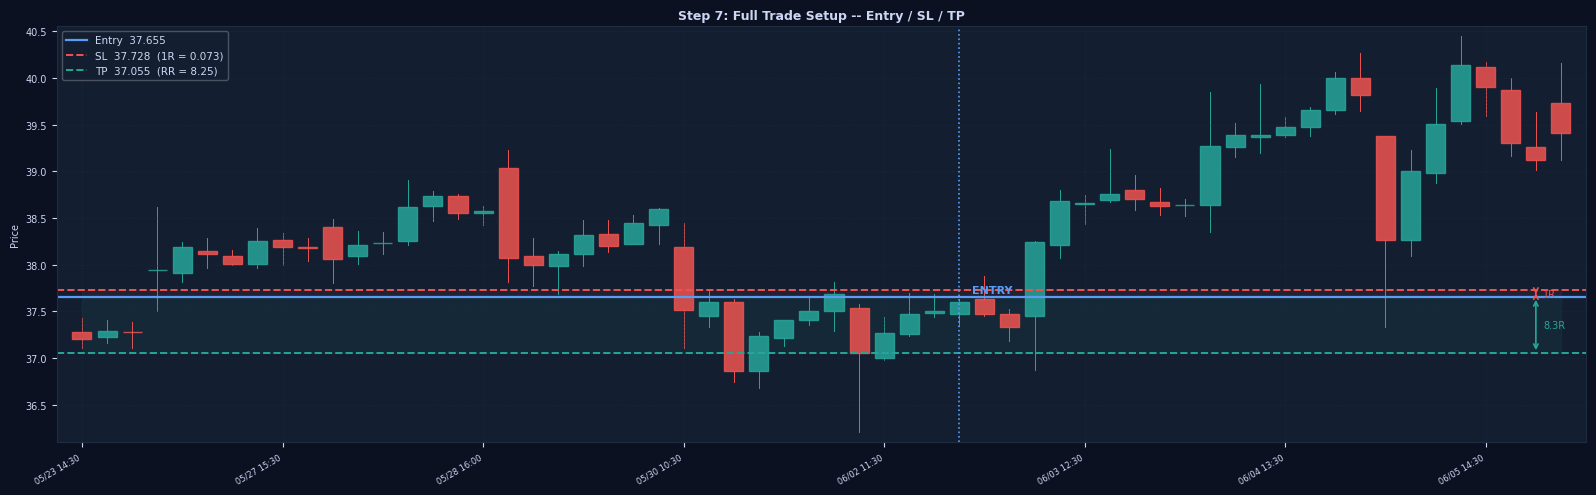

In [11]:
if result.trades:
    trade = result.trades[0]
    entry, sl, tp = trade.entry_price, trade.sl, trade.tp
    direction     = trade.direction
    pos = int((htf_raw['time_key'] <= trade.entry_time).sum()) - 1
    ws  = max(0, pos - 35)
    we  = min(len(htf_raw), pos + 25)
    _htf = htf_raw.iloc[ws:we].reset_index(drop=True)
    entry_bar = pos - ws
    print(f'Trade: {direction}  entry_time={trade.entry_time}')
    print(f'  entry={entry:.3f}  SL={sl:.3f}  TP={tp:.3f}')
    print(f'  RR={trade.planned_rr:.2f}  Result={trade.result}  R={trade.r_multiple:+.2f}')
else:
    _htf = htf.copy()
    mid  = len(_htf) // 2
    entry = _htf.iloc[mid]['close']
    sl    = _htf.iloc[mid]['close'] * 0.97
    tp    = _htf.iloc[mid]['close'] * 1.06
    direction = 'bull'; entry_bar = mid
    print('No real trade found -- using synthetic example')

sl_dist = abs(entry - sl)
rr      = abs(tp - entry) / sl_dist if sl_dist > 0 else 0

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, _htf)
style_ax(ax, 'Step 7: Full Trade Setup -- Entry / SL / TP')
time_ticks(ax, _htf, step=8)

ax.axhline(entry, color=BLUE,  lw=1.6, label=f'Entry  {entry:.3f}')
ax.axhline(sl,    color=RED,   lw=1.4, ls='--', label=f'SL  {sl:.3f}  (1R = {sl_dist:.3f})')
ax.axhline(tp,    color=GREEN, lw=1.4, ls='--', label=f'TP  {tp:.3f}  (RR = {rr:.2f})')
ax.axvline(entry_bar, color=BLUE, lw=1.2, ls=':')
ax.text(entry_bar + 0.5, entry * 1.001, 'ENTRY', color=BLUE, fontsize=8, fontweight='bold')

ax.fill_between(range(len(_htf)), sl,    entry, color=RED,   alpha=0.07)
ax.fill_between(range(len(_htf)), entry, tp,    color=GREEN, alpha=0.07)

xr = len(_htf) - 2
ax.annotate('', xy=(xr, sl), xytext=(xr, entry),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=1.2))
ax.text(xr + 0.3, (sl + entry) / 2, '1R', color=RED, fontsize=7, va='center')
ax.annotate('', xy=(xr, tp), xytext=(xr, entry),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=1.2))
ax.text(xr + 0.3, (tp + entry) / 2, f'{rr:.1f}R', color=GREEN, fontsize=7, va='center')

leg = ax.legend(fontsize=7.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Combined Demo — Multi-Parameter Comparison + Equity Curves


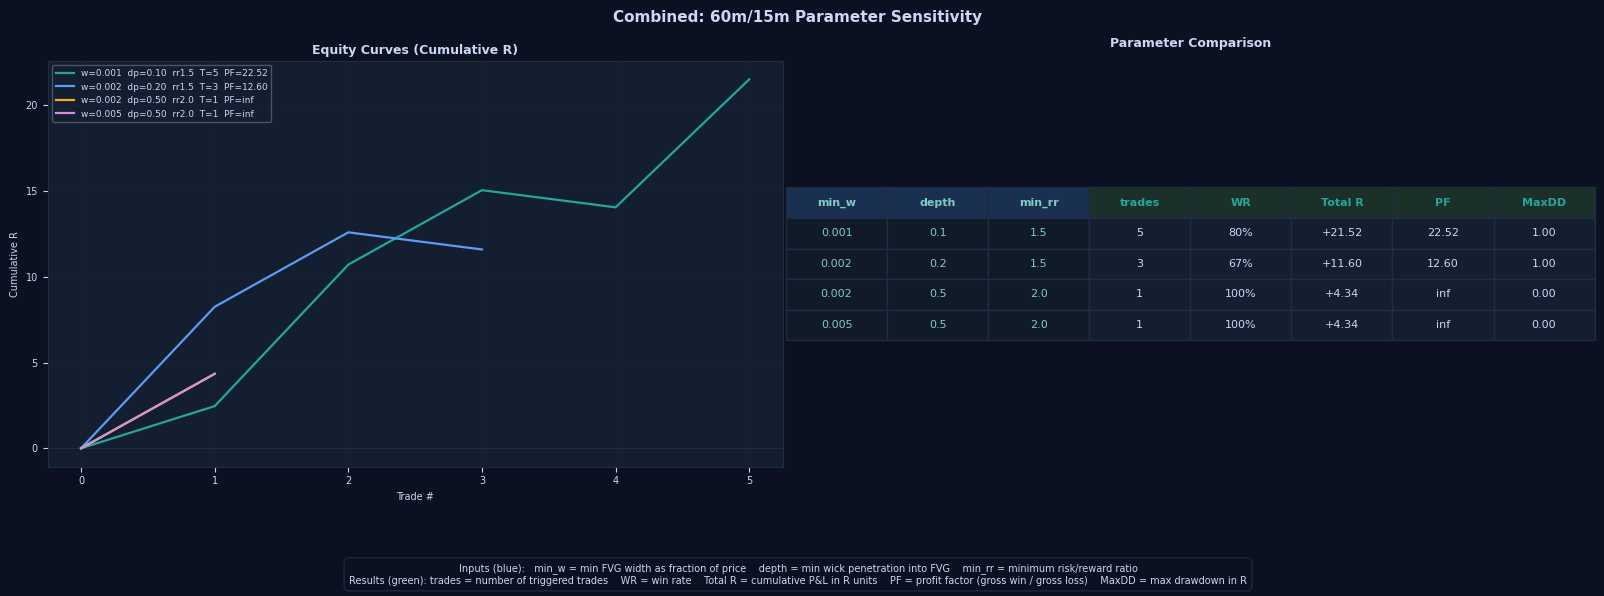

In [12]:
PSETS = [
    dict(fvg_min_width_pct=0.001, fvg_entry_depth_pct=0.10, min_rr=1.5),
    dict(fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.20, min_rr=1.5),
    dict(fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.50, min_rr=2.0),
    dict(fvg_min_width_pct=0.005, fvg_entry_depth_pct=0.50, min_rr=2.0),
]
COLORS4 = [GREEN, BLUE, GOLD, PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.0), facecolor=BG)
fig.subplots_adjust(bottom=0.18)
ax_eq  = axes[0]
ax_tbl = axes[1]
style_ax(ax_eq, 'Equity Curves (Cumulative R)')
ax_eq.axhline(0, color=GRID, lw=0.8)

rows = []
for ps, color in zip(PSETS, COLORS4):
    p = BacktestParams(trend_tf='60m', entry_tf='15m',
                       swing_lookback=2, bos_count=1,
                       sl_buffer_pct=0.001, max_sl_pct=0.010, **ps)
    r = run_backtest(htf_raw, ltf_raw, p)
    lbl = (f"w={ps['fvg_min_width_pct']:.3f}  "
           f"dp={ps['fvg_entry_depth_pct']:.2f}  "
           f"rr{ps['min_rr']:.1f}  "
           f"T={r.n_trades}  PF={r.profit_factor:.2f}")
    if r.trades:
        eq = np.concatenate([[0], np.cumsum([t.r_multiple for t in r.trades])])
        ax_eq.plot(eq, color=color, lw=1.6, label=lbl)
    else:
        ax_eq.plot([0], color=color, lw=1, ls=':', label=lbl + '  (no trades)')
    rows.append([ps['fvg_min_width_pct'], ps['fvg_entry_depth_pct'], ps['min_rr'],
                 r.n_trades, f'{r.win_rate:.0%}',
                 f'{r.total_r:+.2f}', f'{r.profit_factor:.2f}', f'{r.max_drawdown_r:.2f}'])

leg = ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax_eq.set_xlabel('Trade #', fontsize=7)
ax_eq.set_ylabel('Cumulative R', fontsize=7)

# ── Table with input-param vs result column colour coding ────────────────────
ax_tbl.set_facecolor(BG2); ax_tbl.axis('off')
_IN  = {0, 1, 2}        # input parameters
_OUT = {3, 4, 5, 6, 7}  # backtest results
_HDR_IN   = '#1a3050'
_HDR_OUT  = '#1a3028'
_CELL_IN  = '#111a28'
_CELL_OUT = BG2

cols = ['min_w', 'depth', 'min_rr', 'trades', 'WR', 'Total R', 'PF', 'MaxDD']
tbl  = ax_tbl.table(cellText=rows, colLabels=cols, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.1, 1.9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor(_HDR_IN if col in _IN else _HDR_OUT)
        cell.set_text_props(color=CYAN if col in _IN else GREEN, fontweight='bold')
    else:
        cell.set_facecolor(_CELL_IN if col in _IN else _CELL_OUT)
        cell.set_text_props(color=CYAN if col in _IN else FG)
ax_tbl.set_title('Parameter Comparison', color=FG, fontsize=9, fontweight='bold', pad=10)

# ── Abbreviation legend at figure bottom ─────────────────────────────────────
_abbr = (
    "Inputs (blue):   min_w = min FVG width as fraction of price    "
    "depth = min wick penetration into FVG    "
    "min_rr = minimum risk/reward ratio\n"
    "Results (green): trades = number of triggered trades    "
    "WR = win rate    "
    "Total R = cumulative P&L in R units    "
    "PF = profit factor (gross win / gross loss)    "
    "MaxDD = max drawdown in R"
)
fig.text(0.5, 0.02, _abbr, color=FG, fontsize=7, ha='center', va='bottom',
         bbox=dict(fc=BG, ec=GRID, alpha=0.85, pad=5, boxstyle='round,pad=0.5'))

plt.suptitle('Combined: 60m/15m Parameter Sensitivity', color=FG, fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()


## Step 8 — SL Parameter Sweep

SL is placed beyond the nearest HTF swing low/high, governed by:

| Parameter | Description |
|-----------|-------------|
| `sl_buffer_pct` | Extra buffer beyond the swing point (% of price) |
| `max_sl_pct` | Skip the trade if SL is further than this from entry |

Fixed: `depth-only` mode, `fvg_entry_depth_pct=0.10`.


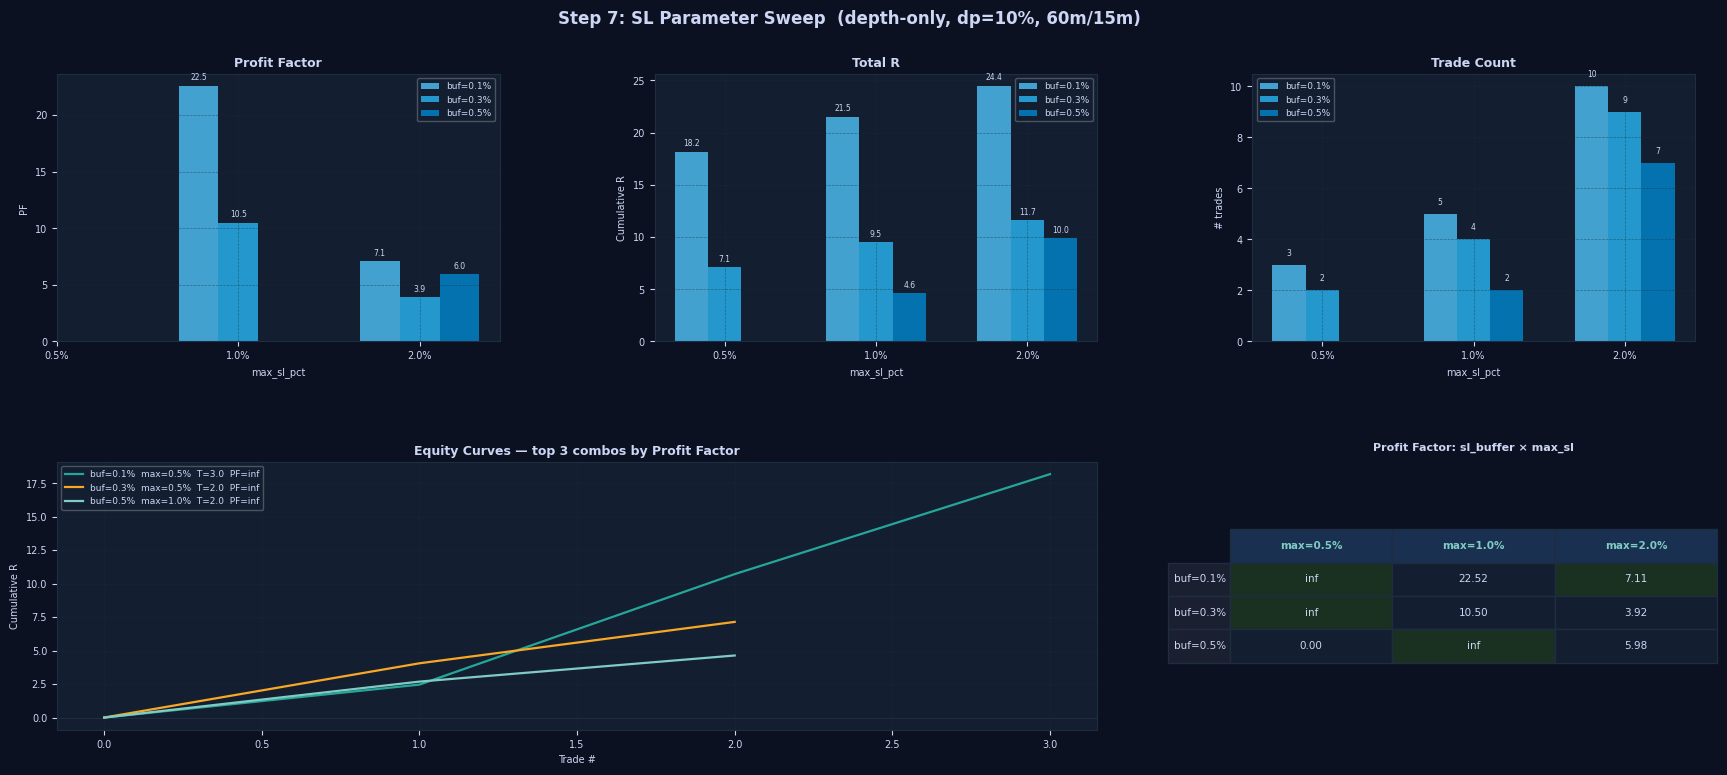

 sl_buf  max_sl  n_trades  win_rate   total_r  profit_factor  max_dd
  0.001   0.005         3  1.000000 18.180121            inf     0.0
  0.001   0.010         5  0.800000 21.523330      22.523330     1.0
  0.001   0.020        10  0.600000 24.427156       7.106789     2.0
  0.003   0.005         2  1.000000  7.144358            inf     0.0
  0.003   0.010         4  0.750000  9.503213      10.503213     1.0
  0.003   0.020         9  0.555556 11.670046       3.917511     2.0
  0.005   0.005         0  0.000000  0.000000       0.000000     0.0
  0.005   0.010         2  1.000000  4.635078            inf     0.0
  0.005   0.020         7  0.714286  9.957304       5.978652     1.0


In [13]:
SL_BUFFERS  = [0.001, 0.003, 0.005]
MAX_SLS     = [0.005, 0.010, 0.020]
SL_BASE = dict(trend_tf="60m", entry_tf="15m",
               swing_lookback=2, bos_count=1,
               fvg_min_width_pct=0.002,
               fvg_entry_depth_pct=0.10,
               require_ltf_confirmation=False,
               min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
sl_records   = []
sl_trade_map = {}
for buf, msl in itertools.product(SL_BUFFERS, MAX_SLS):
    p = BacktestParams(**SL_BASE, sl_buffer_pct=buf, max_sl_pct=msl)
    r = run_backtest(htf_raw, ltf_raw, p)
    sl_records.append(dict(
        sl_buf=buf, max_sl=msl,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    sl_trade_map[(buf, msl)] = [t.r_multiple for t in r.trades]

df_sl = pd.DataFrame(sl_records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

BUF_COLORS = ["#4fc3f7", "#29b6f6", "#0288d1"]   # light→dark blue per buffer
bar_w = 0.22
x     = np.arange(len(MAX_SLS))

# ── Bar charts ───────────────────────────────────────────────────────────────
for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    for k, (buf, color) in enumerate(zip(SL_BUFFERS, BUF_COLORS)):
        vals = [df_sl.loc[(df_sl.sl_buf == buf) & (df_sl.max_sl == msl), col].values[0]
                for msl in MAX_SLS]
        offset = (k - 1) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"buf={buf:.1%}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m:.1%}" for m in MAX_SLS], fontsize=7)
    ax.set_xlabel("max_sl_pct", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

# ── Equity curves (top-3 by PF) ──────────────────────────────────────────────
style_ax(ax_eq, "Equity Curves — top 3 combos by Profit Factor")
ax_eq.axhline(0, color=GRID, lw=0.8)
top3 = df_sl[df_sl.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
eq_colors = [GREEN, GOLD, CYAN]
for i, (_, row) in enumerate(top3.iterrows()):
    rs = sl_trade_map[(row.sl_buf, row.max_sl)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"buf={row.sl_buf:.1%}  max={row.max_sl:.1%}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=eq_colors[i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table (PF) ─────────────────────────────────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot_pf = df_sl.pivot(index="sl_buf", columns="max_sl", values="profit_factor")
pivot_pf.index   = [f"{v:.1%}" for v in pivot_pf.index]
pivot_pf.columns = [f"max={v:.1%}" for v in pivot_pf.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot_pf.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=[f"buf={l}" for l in pivot_pf.index],
                   colLabels=list(pivot_pf.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        # highlight best PF in green
        try:
            v = float(_rows[row - 1][col])
            best = max(float(r[col]) for r in _rows)
            fc = "#1a3020" if v == best else BG2
        except (ValueError, IndexError):
            fc = BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: sl_buffer × max_sl",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 7: SL Parameter Sweep  (depth-only, dp=10%, 60m/15m)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_sl.to_string(index=False))


## Step 9 — Swing Parameter Sweep

`swing_lookback` and `bos_count` have the largest effect on trend sensitivity.

| Parameter | Effect |
|-----------|--------|
| `swing_lookback` | Larger -> fewer, more stable swings; smaller -> more sensitive, noisier |
| `bos_count` | Larger -> trend harder to change, more stable but more lag |


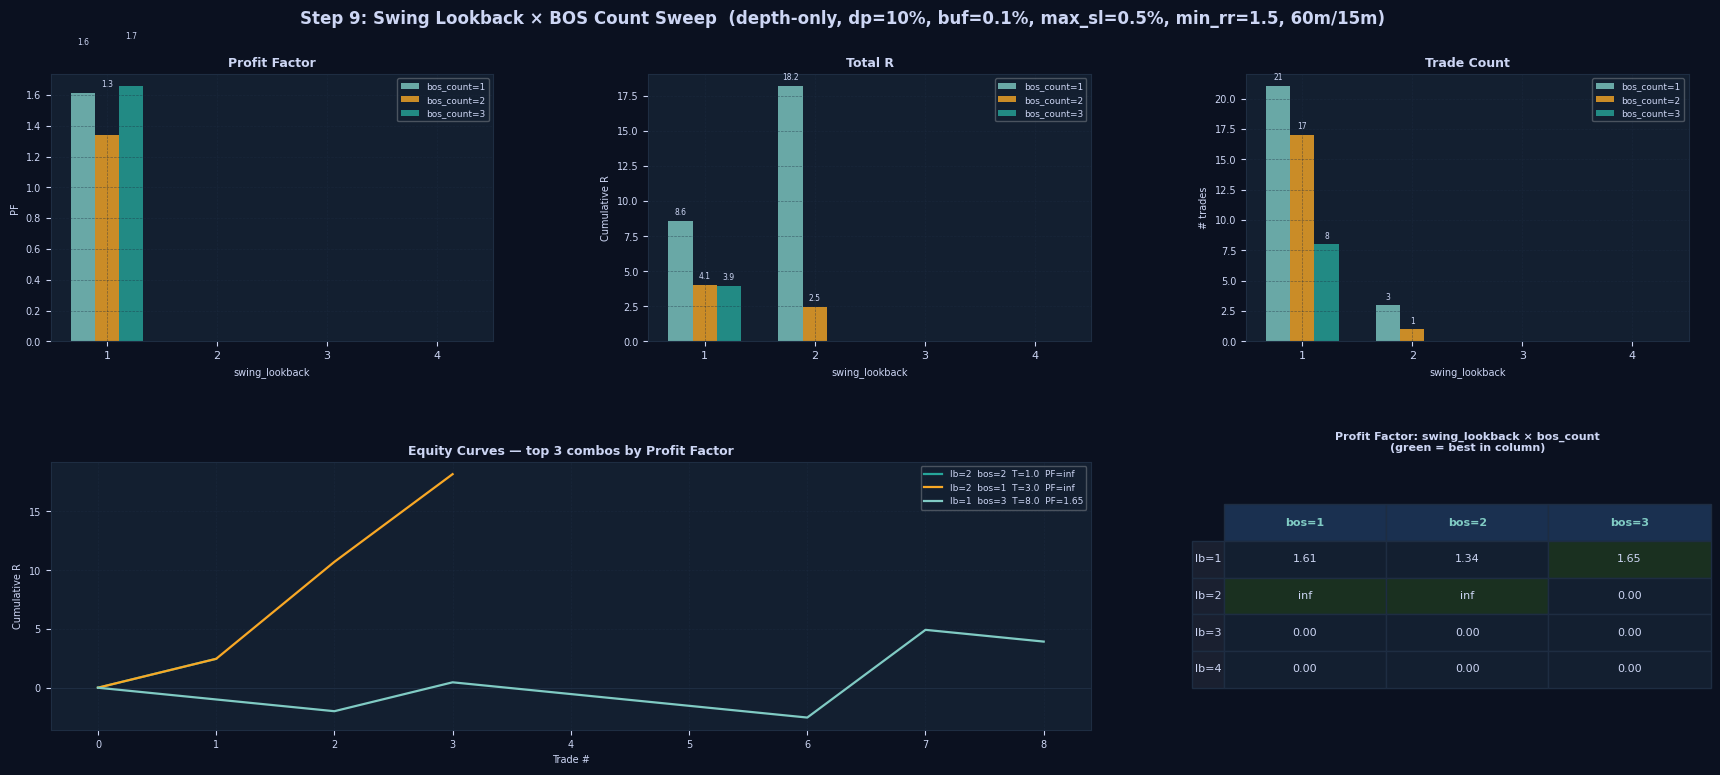

 lookback  bos_count  n_trades  win_rate   total_r  profit_factor  max_dd
        1          1        21  0.333333  8.563322       1.611666     4.0
        1          2        17  0.294118  4.060848       1.338404     4.0
        1          3         8  0.250000  3.925891       1.654315     3.0
        2          1         3  1.000000 18.180121            inf     0.0
        2          2         1  1.000000  2.459927            inf     0.0
        2          3         0  0.000000  0.000000       0.000000     0.0
        3          1         0  0.000000  0.000000       0.000000     0.0
        3          2         0  0.000000  0.000000       0.000000     0.0
        3          3         0  0.000000  0.000000       0.000000     0.0
        4          1         0  0.000000  0.000000       0.000000     0.0
        4          2         0  0.000000  0.000000       0.000000     0.0
        4          3         0  0.000000  0.000000       0.000000     0.0


In [14]:
LOOKBACKS  = [1, 2, 3, 4]
BOS_COUNTS = [1, 2, 3]
LB_BASE = dict(trend_tf="60m", entry_tf="15m",
               fvg_min_width_pct=0.002,
               fvg_entry_depth_pct=0.10,
               require_ltf_confirmation=False,
               sl_buffer_pct=0.001, max_sl_pct=0.005,
               min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
lb_records   = []
lb_trade_map = {}
for lb, bc in itertools.product(LOOKBACKS, BOS_COUNTS):
    p = BacktestParams(**LB_BASE, swing_lookback=lb, bos_count=bc)
    r = run_backtest(htf_raw, ltf_raw, p)
    lb_records.append(dict(
        lookback=lb, bos_count=bc,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    lb_trade_map[(lb, bc)] = [t.r_multiple for t in r.trades]

df_lb = pd.DataFrame(lb_records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

BC_COLORS = [CYAN, GOLD, GREEN]
bar_w = 0.22
x     = np.arange(len(LOOKBACKS))

for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    for k, (bc, color) in enumerate(zip(BOS_COUNTS, BC_COLORS)):
        vals = [df_lb.loc[(df_lb.lookback == lb) & (df_lb.bos_count == bc), col].values[0]
                for lb in LOOKBACKS]
        offset = (k - 1) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"bos_count={bc}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([str(lb) for lb in LOOKBACKS], fontsize=8)
    ax.set_xlabel("swing_lookback", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

# ── Equity curves (top-3 by PF) ──────────────────────────────────────────────
style_ax(ax_eq, "Equity Curves — top 3 combos by Profit Factor")
ax_eq.axhline(0, color=GRID, lw=0.8)
top3 = df_lb[df_lb.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
eq_colors = [GREEN, GOLD, CYAN]
for i, (_, row) in enumerate(top3.iterrows()):
    rs = lb_trade_map[(row.lookback, row.bos_count)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"lb={int(row.lookback)}  bos={int(row.bos_count)}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=eq_colors[i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table (PF) — highlight best per column ─────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot_lb = df_lb.pivot(index="lookback", columns="bos_count", values="profit_factor")
pivot_lb.index   = [f"lb={v}" for v in pivot_lb.index]
pivot_lb.columns = [f"bos={v}" for v in pivot_lb.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot_lb.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=list(pivot_lb.index),
                   colLabels=list(pivot_lb.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 2.2)
col_maxes = [max(float(_rows[r][c]) for r in range(len(_rows)))
             for c in range(len(_rows[0]))]
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        v  = float(_rows[row - 1][col])
        fc = "#1a3020" if v == col_maxes[col] else BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: swing_lookback × bos_count\n(green = best in column)",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 9: Swing Lookback × BOS Count Sweep  (depth-only, dp=10%, buf=0.1%, max_sl=0.5%, min_rr=1.5, 60m/15m)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_lb.to_string(index=False))


## Step 10 — Displacement Filter Sweep

`displacement_required` gates whether the FVG must originate from a displacement candle.
A displacement candle has range > `displacement_atr_mult` x mean range of prior N bars
and body ratio >= 50%.

Sweep: `displacement_required` [False, True] x `lookback` [3,5,10] x `atr_mult` [1.5,2.0,3.0].


displacement=False : T=  3  PF=inf  TotalR=18.2

 lookback  atr_mult  n_trades  win_rate   total_r  profit_factor  max_dd
        3       1.5         2       1.0 15.720194            inf     0.0
        3       2.0         2       1.0 15.720194            inf     0.0
        3       3.0         1       1.0  8.254230            inf     0.0
        5       1.5         2       1.0 15.720194            inf     0.0
        5       2.0         2       1.0 15.720194            inf     0.0
        5       3.0         1       1.0  8.254230            inf     0.0
       10       1.5         2       1.0 15.720194            inf     0.0
       10       2.0         2       1.0 15.720194            inf     0.0
       10       3.0         0       0.0  0.000000            0.0     0.0


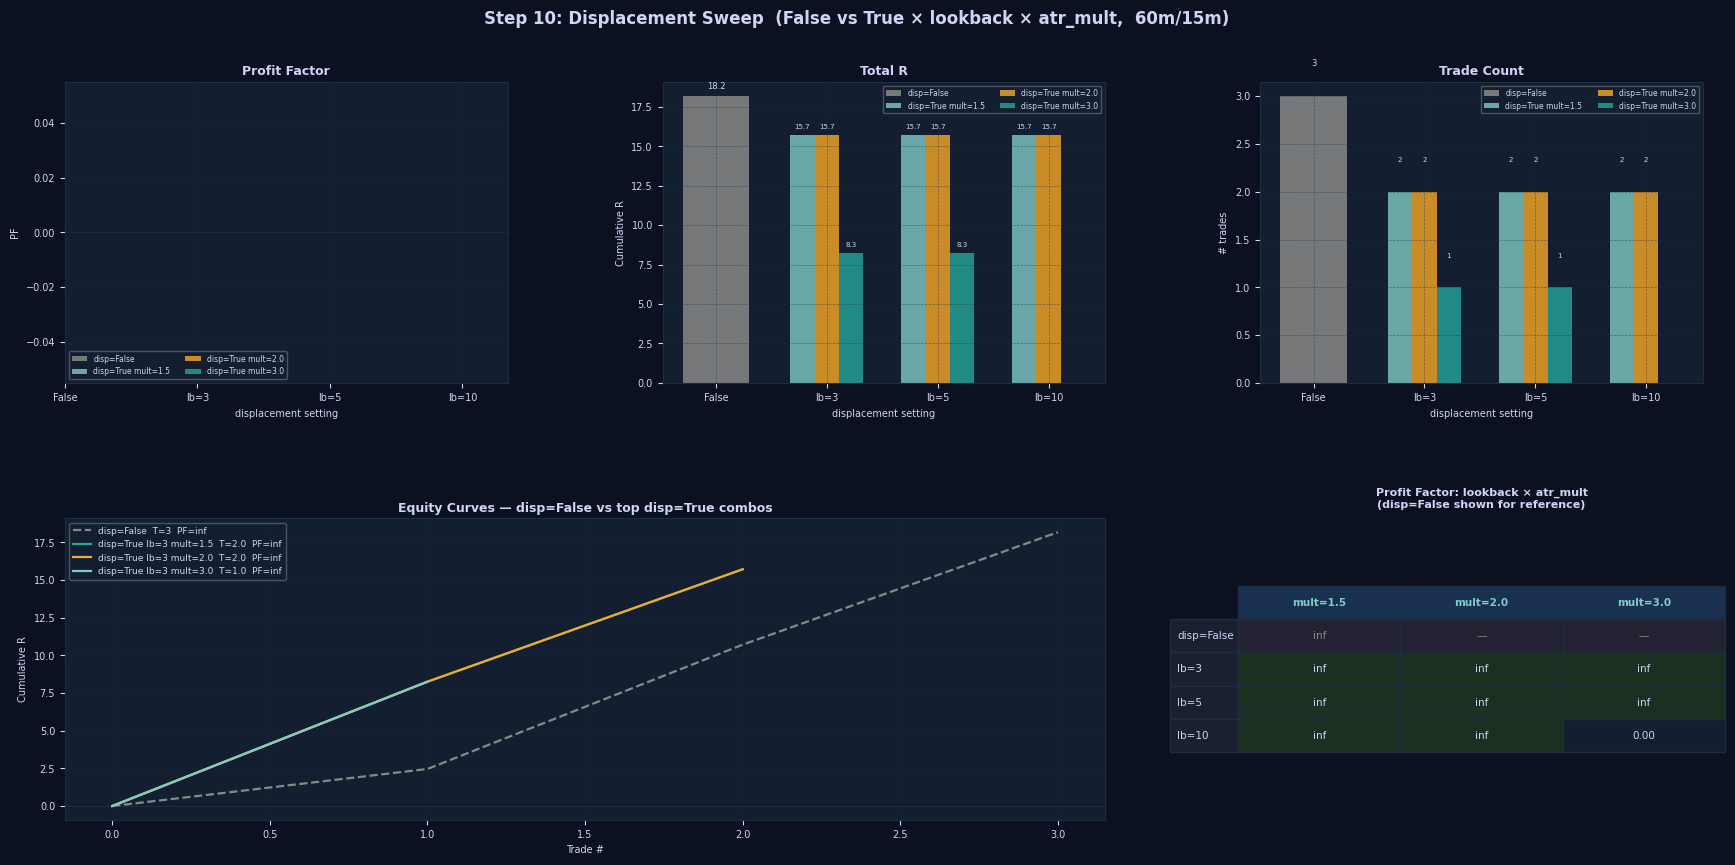

In [15]:
LOOKBACKS = [3, 5, 10]
ATR_MULTS = [1.5, 2.0, 3.0]
DISP_BASE = dict(
    trend_tf="60m", entry_tf="15m",
    swing_lookback=2, bos_count=1,
    fvg_min_width_pct=0.002,
    fvg_entry_depth_pct=0.10,
    require_ltf_confirmation=False,
    sl_buffer_pct=0.001, max_sl_pct=0.005,
    min_rr=1.5,
)

# ── Run: displacement_required=False (single run, lookback/mult irrelevant) ──
p_off  = BacktestParams(**DISP_BASE, displacement_required=False)
r_off  = run_backtest(htf_raw, ltf_raw, p_off)
off_rs = [t.r_multiple for t in r_off.trades]

# ── Run: displacement_required=True, sweep lookback × atr_mult ───────────────
disp_records   = []
disp_trade_map = {}
for lb, mult in itertools.product(LOOKBACKS, ATR_MULTS):
    p = BacktestParams(**DISP_BASE,
                       displacement_required=True,
                       displacement_lookback=lb,
                       displacement_atr_mult=mult)
    r = run_backtest(htf_raw, ltf_raw, p)
    disp_records.append(dict(
        lookback=lb, atr_mult=mult,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    disp_trade_map[(lb, mult)] = [t.r_multiple for t in r.trades]

df_disp = pd.DataFrame(disp_records)

print(f"displacement=False : T={r_off.n_trades:3d}  PF={r_off.profit_factor:.2f}  TotalR={r_off.total_r:.1f}")
print()
print(df_disp.to_string(index=False))

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

MULT_COLORS = {1.5: CYAN, 2.0: GOLD, 3.0: GREEN}
# For bar positioning: False occupies slot 0, True combos follow
x_labels = ["False"] + [f"lb={lb}" for lb in LOOKBACKS]
x_pos    = np.arange(len(x_labels))

# ── Bar charts ────────────────────────────────────────────────────────────────
for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    ax.axhline(0, color=GRID, lw=0.5)

    # displacement=False bar (no grouping needed)
    false_val = getattr(r_off, col if col != "n_trades" else "n_trades")
    false_val = r_off.n_trades if col == "n_trades" else getattr(r_off, col)
    ax.bar(0, false_val, width=0.6, color='#888888', alpha=0.85, label="disp=False")
    fmt = f"{false_val:.1f}" if col != "n_trades" else str(int(false_val))
    if false_val != 0:
        ax.text(0, false_val + max(abs(false_val)*0.02, 0.3), fmt,
                ha="center", va="bottom", fontsize=6, color=FG)

    # displacement=True bars grouped by atr_mult
    bar_w = 0.22
    for k, (mult, color) in enumerate(MULT_COLORS.items()):
        vals = [df_disp.loc[(df_disp.lookback == lb) & (df_disp.atr_mult == mult), col].values[0]
                for lb in LOOKBACKS]
        offsets = np.arange(1, len(LOOKBACKS)+1) + (k-1)*bar_w
        bars = ax.bar(offsets, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"disp=True mult={mult}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+max(abs(v)*0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5, color=FG)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_xlabel("displacement setting", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.legend(fontsize=5.5, framealpha=0.3, labelcolor=FG, ncol=2)

# ── Equity curves: False + top-3 True combos ─────────────────────────────────
style_ax(ax_eq, "Equity Curves — disp=False vs top disp=True combos")
ax_eq.axhline(0, color=GRID, lw=0.8)
if off_rs:
    eq = np.concatenate([[0], np.cumsum(off_rs)])
    ax_eq.plot(eq, color='#888888', lw=1.6, ls='--',
               label=f"disp=False  T={r_off.n_trades}  PF={r_off.profit_factor:.2f}")

top3 = df_disp[df_disp.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
for i, (_, row) in enumerate(top3.iterrows()):
    rs = disp_trade_map[(row.lookback, row.atr_mult)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"disp=True lb={int(row.lookback)} mult={row.atr_mult}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=[GREEN,GOLD,CYAN][i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table: PF (disp=True only) ─────────────────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot = df_disp.pivot(index="lookback", columns="atr_mult", values="profit_factor")
pivot.index   = [f"lb={v}" for v in pivot.index]
pivot.columns = [f"mult={v}" for v in pivot.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot.values]
# add False row at top
false_pf = f"{r_off.profit_factor:.2f}"
_rows_full = [[false_pf, "—", "—"]] + _rows
row_labels = ["disp=False"] + list(pivot.index)
col_maxes  = [max(float(r[c]) for r in _rows if r[c] != "—")
              for c in range(len(_rows[0]))]
tbl = ax_tbl.table(cellText=_rows_full,
                   rowLabels=row_labels,
                   colLabels=list(pivot.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    elif row == 1:  # disp=False row
        cell.set_facecolor("#222233")
        cell.set_text_props(color='#888888')
    else:
        try:
            v  = float(_rows_full[row-1][col])
            fc = "#1a3020" if v == col_maxes[col] else BG2
        except ValueError:
            fc = BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: lookback × atr_mult\n(disp=False shown for reference)",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle(
    "Step 10: Displacement Sweep  (False vs True × lookback × atr_mult,  60m/15m)",
    color=FG, fontsize=12, fontweight="bold",
)
plt.show()


## Step 11 — KD Channel Trend (`kd_trend`)

An alternative HTF trend detector based on **EMA channel momentum** rather than structural breaks.

| Component | Formula | Meaning |
|-----------|---------|--------|
| Fast channel | EMA(High, fast) / EMA(Low, fast) | Short-term price envelope |
| Slow channel | EMA(High, slow) / EMA(Low, slow) | Long-term price envelope |
| **Spread** | MID1 - MID2 | Fast channel position vs slow |
| **Width** | delta-spread per bar | Rate-of-change of the spread |

Trend = `avg(Width[-window:])`:  
- avg_width > threshold -> **bull**  
- avg_width < -threshold -> **bear**  
- |avg_width| <= threshold -> **flat** (no signal)

`kd_window` controls how many recent bars to average -- shorter reacts faster but is noisier.  
In `bos_choch+kd` combined mode both BOS/CHoCH and KD must agree on direction.


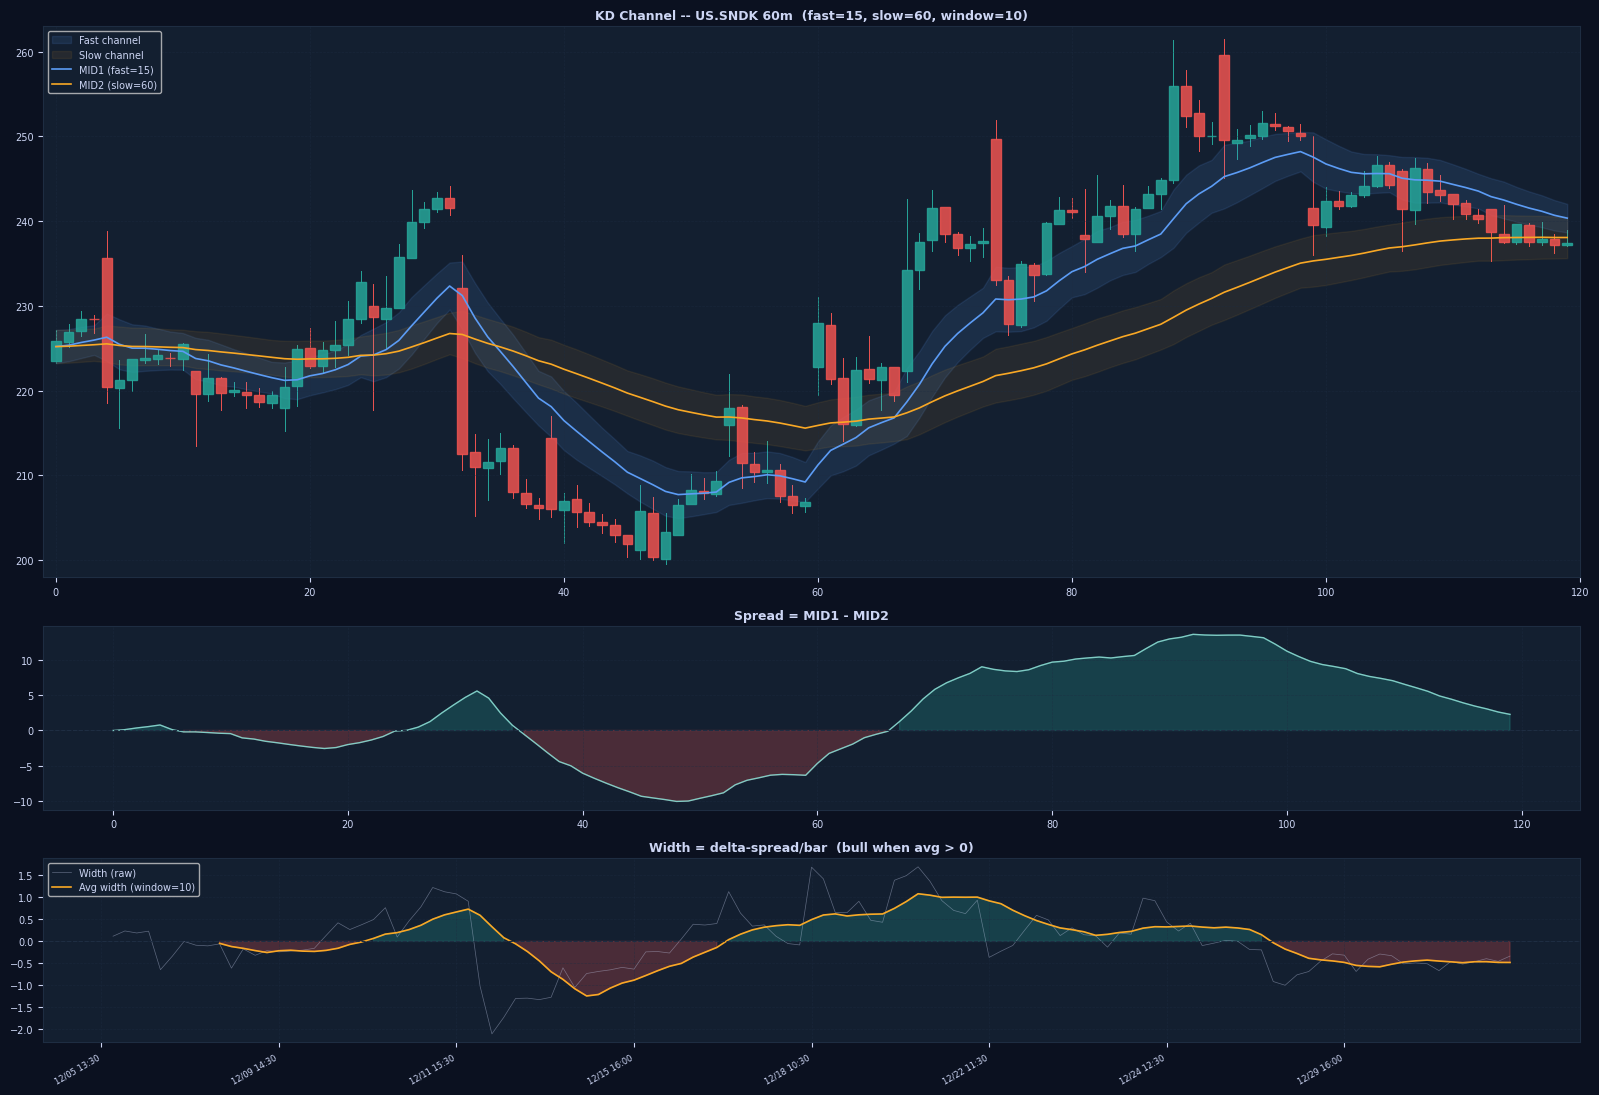

In [16]:
# KD indicator: three-panel chart
FAST, SLOW, WINDOW = 15, 60, 10
htf_kd = htf_raw.tail(120).reset_index(drop=True)
kd = compute_kd(htf_kd, fast=FAST, slow=SLOW)

fig, axes = plt.subplots(3, 1, figsize=(16, 11), facecolor=BG,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.subplots_adjust(hspace=0.08)

# Panel 1: price + channels
ax = axes[0]
draw_candles(ax, htf_kd)
ax.fill_between(range(len(htf_kd)), kd['lo1'], kd['up1'], alpha=0.12, color=BLUE, label='Fast channel')
ax.fill_between(range(len(htf_kd)), kd['lo2'], kd['up2'], alpha=0.08, color=GOLD, label='Slow channel')
ax.plot(kd['mid1'], color=BLUE, lw=1.2, label=f'MID1 (fast={FAST})')
ax.plot(kd['mid2'], color=GOLD, lw=1.2, label=f'MID2 (slow={SLOW})')
ax.legend(loc='upper left', fontsize=7, facecolor=BG2, labelcolor=FG, framealpha=0.8)
style_ax(ax, f'KD Channel -- {CODE} 60m  (fast={FAST}, slow={SLOW}, window={WINDOW})')

# Panel 2: spread
ax2 = axes[1]
ax2.plot(kd['spread'], color=CYAN, lw=1.0)
ax2.axhline(0, color=GRID, lw=0.8, ls='--')
ax2.fill_between(range(len(kd)), kd['spread'], 0, where=kd['spread'] > 0, alpha=0.25, color=GREEN)
ax2.fill_between(range(len(kd)), kd['spread'], 0, where=kd['spread'] < 0, alpha=0.25, color=RED)
style_ax(ax2, 'Spread = MID1 - MID2')

# Panel 3: width
ax3 = axes[2]
avg_width = kd['width'].rolling(WINDOW).mean()
ax3.plot(kd['width'], color=FG, lw=0.5, alpha=0.4, label='Width (raw)')
ax3.plot(avg_width, color=GOLD, lw=1.2, label=f'Avg width (window={WINDOW})')
ax3.axhline(0, color=GRID, lw=0.8, ls='--')
ax3.fill_between(range(len(avg_width)), avg_width, 0, where=avg_width > 0, alpha=0.25, color=GREEN)
ax3.fill_between(range(len(avg_width)), avg_width, 0, where=avg_width < 0, alpha=0.25, color=RED)
ax3.legend(loc='upper left', fontsize=7, facecolor=BG2, labelcolor=FG)
style_ax(ax3, 'Width = delta-spread/bar  (bull when avg > 0)')
time_ticks(ax3, htf_kd, step=15)
plt.tight_layout()
plt.show()


### KD Trend Zone Overlay on Price

Background shading shows the real-time trend classification at each bar.


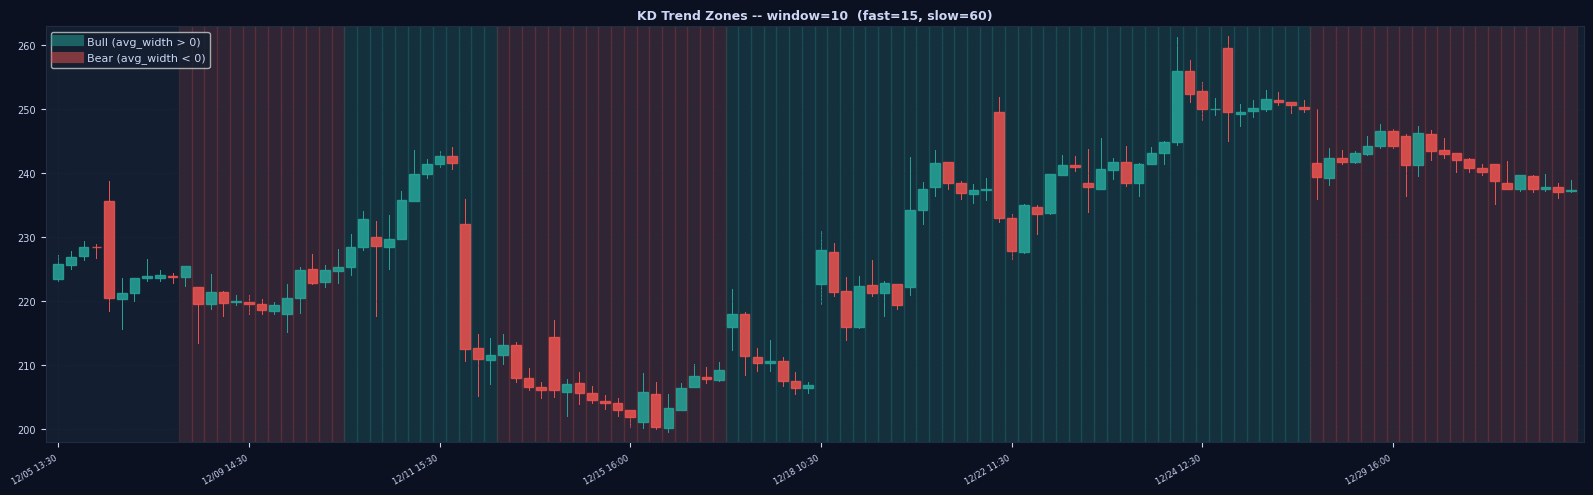

In [17]:
fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf_kd)

avg_w = kd['width'].rolling(WINDOW).mean()
for i in range(WINDOW, len(htf_kd)):
    w = avg_w.iloc[i]
    if pd.isna(w):
        continue
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.13,
               color=GREEN if w > 0 else RED, zorder=0)

ax.plot([], [], color=GREEN, alpha=0.5, lw=8, label='Bull (avg_width > 0)')
ax.plot([], [], color=RED,   alpha=0.5, lw=8, label='Bear (avg_width < 0)')
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
style_ax(ax, f'KD Trend Zones -- window={WINDOW}  (fast={FAST}, slow={SLOW})')
time_ticks(ax, htf_kd, step=15)
plt.tight_layout()
plt.show()


### `kd_window` Parameter Sweep

Shorter windows react faster but flip more often.
Longer windows are smoother but lag real trend changes.


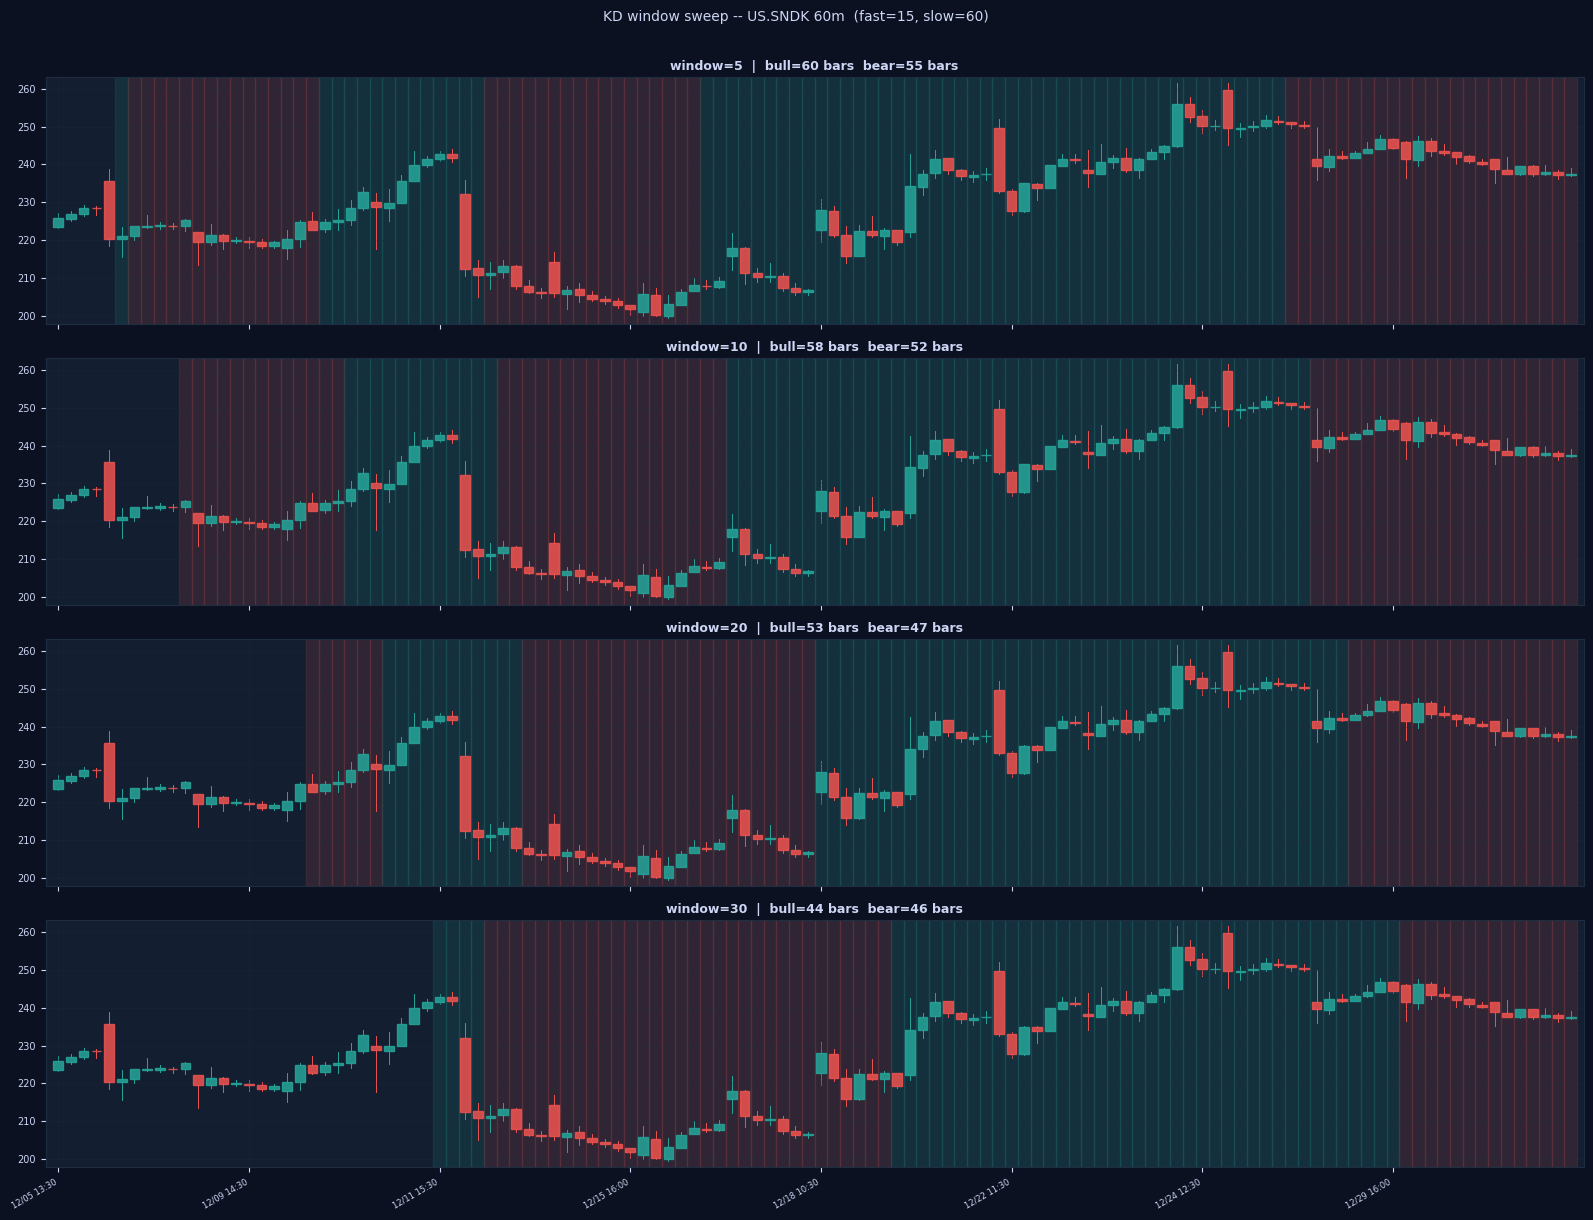

In [18]:
WINDOWS = [5, 10, 20, 30]
fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(16, 3 * len(WINDOWS)),
                          facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.12)

raw_width = kd['width']
for ax, win in zip(axes, WINDOWS):
    avg_w = raw_width.rolling(win).mean()
    draw_candles(ax, htf_kd)
    for i in range(win, len(htf_kd)):
        w = avg_w.iloc[i]
        if pd.isna(w):
            continue
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13,
                   color=GREEN if w > 0 else RED, zorder=0)
    bull_bars = int((avg_w > 0).sum())
    bear_bars = int((avg_w < 0).sum())
    style_ax(ax, f'window={win}  |  bull={bull_bars} bars  bear={bear_bars} bars')

time_ticks(axes[-1], htf_kd, step=15)
plt.suptitle(f'KD window sweep -- {CODE} 60m  (fast={FAST}, slow={SLOW})',
             color=FG, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


### `flat_threshold` Effect

Filters out bars where momentum is too weak to classify as bull or bear.
Higher threshold -> more flat bars -> fewer but higher-conviction signals.


|avg_width| percentiles -- p25=0.2288  p50=0.4027  p75=0.6031
  -> flat_threshold=0 keeps all; ~0.4027 filters ~50% weakest bars
threshold bull% bear% flat%  classified
   0.0000  30.9  18.2  50.9          54
   0.2288  30.9  18.2  50.9          54
   0.4027  30.9  18.2  50.9          54
   0.6031  30.9  18.2  50.9          54


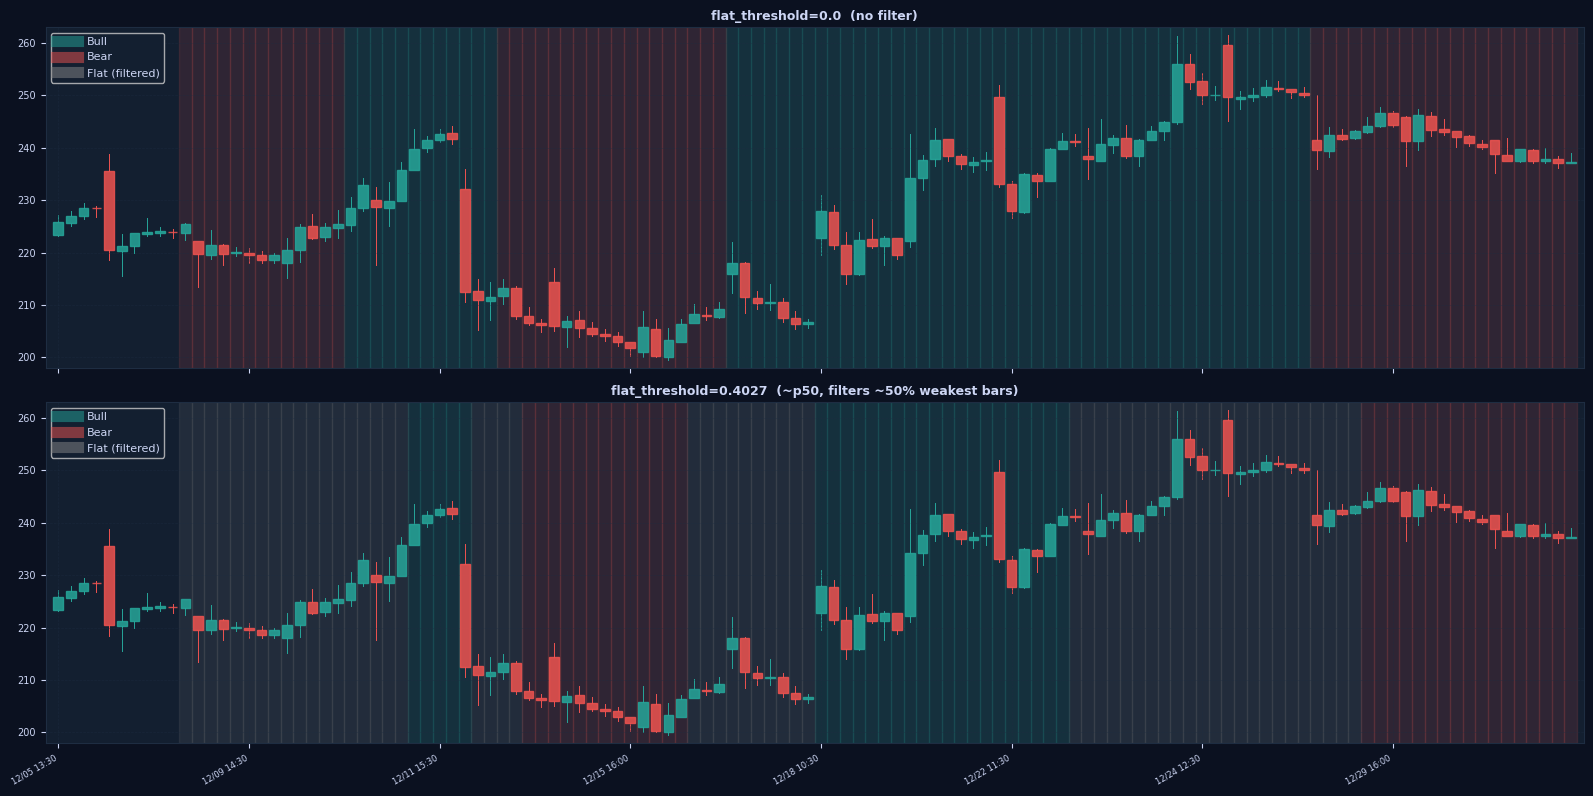

In [19]:
# Thresholds are in price units (dollars/bar) -- must scale with the stock price.
# Derive from the actual width distribution so the sweep is always meaningful.
import numpy as np
avg_w_series = kd['width'].rolling(WINDOW).mean().dropna().abs()
p25, p50, p75 = np.percentile(avg_w_series, [25, 50, 75])
print(f'|avg_width| percentiles -- p25={p25:.4f}  p50={p50:.4f}  p75={p75:.4f}')
print(f'  -> flat_threshold=0 keeps all; ~{p50:.4f} filters ~50% weakest bars')

THRESHOLDS = [0.0, round(p25, 4), round(p50, 4), round(p75, 4)]

rows = []
for thr in THRESHOLDS:
    classified = []
    for i in range(WINDOW, len(htf_kd)):
        t = kd_trend(htf_kd.iloc[:i+1], fast=FAST, slow=SLOW,
                     window=WINDOW, flat_threshold=thr)
        classified.append(t)
    total = len(classified)
    bull  = classified.count('bull')
    bear  = classified.count('bear')
    flat  = classified.count(None)
    rows.append({'threshold': f'{thr:.4f}',
                 'bull%': f'{bull/total*100:.1f}',
                 'bear%': f'{bear/total*100:.1f}',
                 'flat%': f'{flat/total*100:.1f}',
                 'classified': bull + bear})

df_thr = pd.DataFrame(rows)
print(df_thr.to_string(index=False))

# Visualise: no filter vs p50 threshold side-by-side
fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

for ax, thr, title in [
    (axes[0], 0.0, 'flat_threshold=0.0  (no filter)'),
    (axes[1], p50, f'flat_threshold={p50:.4f}  (~p50, filters ~50% weakest bars)'),
]:
    draw_candles(ax, htf_kd)
    avg_w = kd['width'].rolling(WINDOW).mean()
    for i in range(WINDOW, len(htf_kd)):
        w = avg_w.iloc[i]
        if pd.isna(w):
            continue
        if   w > thr:  color = GREEN
        elif w < -thr: color = RED
        else:           color = '#888888'
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=color, zorder=0)
    ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
    ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
    ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat (filtered)')
    ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
    style_ax(ax, title)

time_ticks(axes[-1], htf_kd, step=15)
plt.tight_layout()
plt.show()


### ATR-Normalised Momentum Filter (Recommended)

**Problem with `flat_threshold`:** it is in price units ($/bar) and must be tuned per-stock.
A threshold that works for a $30 stock is far too small for a $200 stock.

**Solution — `atr_threshold`:** divide `avg_width` by the bar's ATR so the signal is
dimensionless and scale-invariant:

```
normalised_momentum = |avg_width| / ATR_14
```

| Condition | Classification |
|-----------|----------------|
| ratio >= `atr_threshold` AND avg_width > 0 | **bull** |
| ratio >= `atr_threshold` AND avg_width < 0 | **bear** |
| ratio < `atr_threshold` | **flat** |

**Calibration target:** the Apr 15-22 4H SNDK period is visually choppy (price oscillates
~$1 around a flat mean) but KD classifies it as *bull* because the EMA spread is still
elevated from the prior run-up. During this period `width/ATR` drops to 0.01-0.05 while
trending periods sit at 0.10-0.30 — a clear separation.

A threshold of **0.05** correctly re-labels the choppy period as flat while preserving
all strong trend bars.


ratio stats:  min=0.003  p25=0.041  p50=0.072  p75=0.106  max=0.153


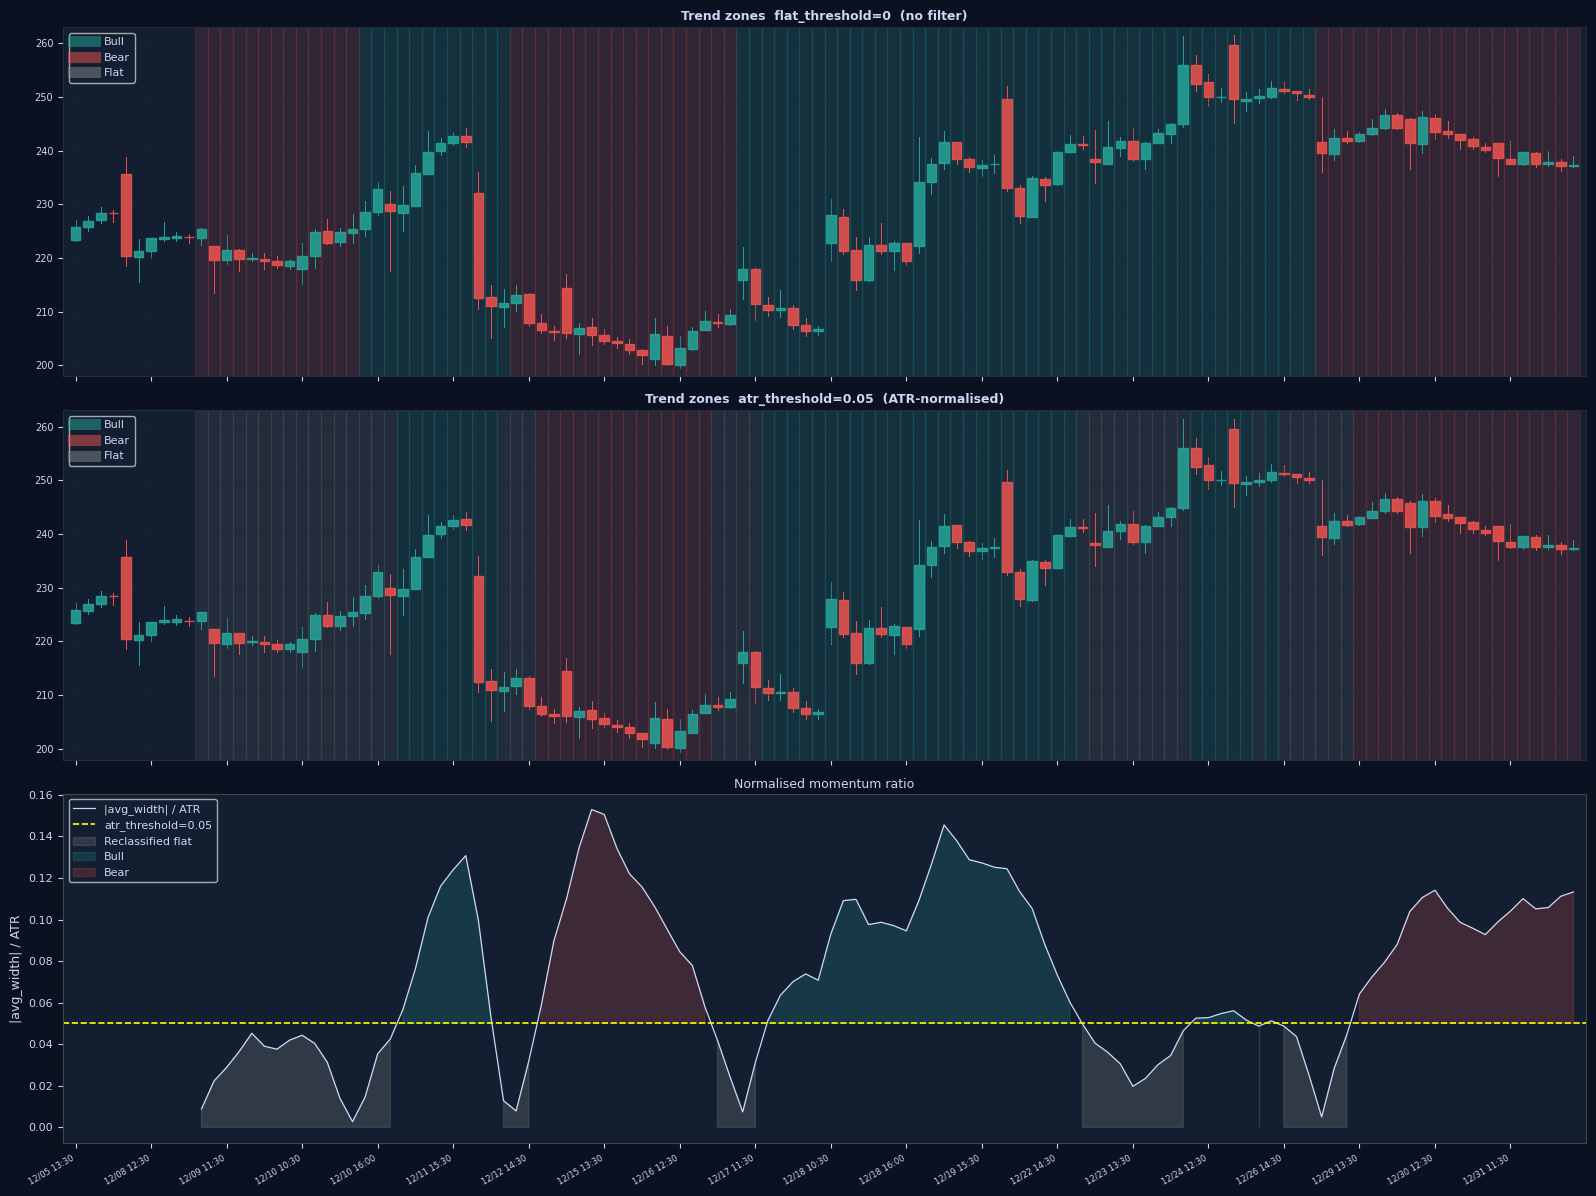

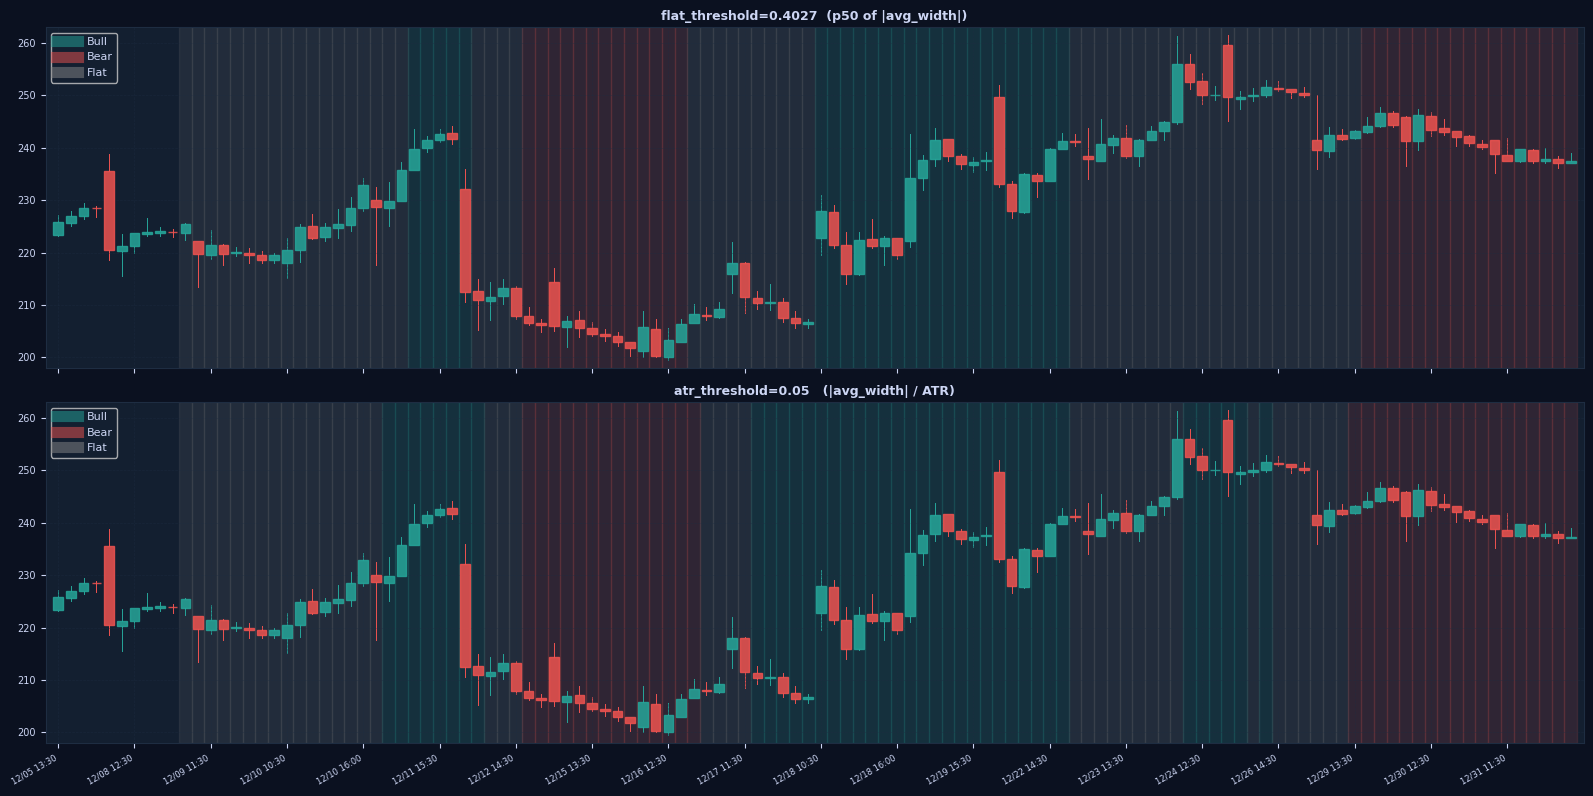

In [20]:
# ATR-normalised momentum: |avg_width| / ATR -- scale-invariant across stocks
# Use same tail(120) window as cell 35 for direct comparison.
import numpy as np

FAST, SLOW, WINDOW = 15, 60, 10
ATR_PERIOD = 14
htf_kd = htf_raw.tail(120).reset_index(drop=True)
kd = compute_kd(htf_kd, fast=FAST, slow=SLOW, atr_period=ATR_PERIOD)

avg_w   = kd['width'].rolling(WINDOW).mean()
avg_atr = kd['atr'].rolling(WINDOW).mean()
ratio   = (avg_w.abs() / avg_atr).replace([np.inf, -np.inf], np.nan)

ATR_THR = 0.05   # bars with ratio < this are reclassified as flat

print(f'ratio stats:  min={ratio.dropna().min():.3f}'
      f'  p25={np.percentile(ratio.dropna(), 25):.3f}'
      f'  p50={np.percentile(ratio.dropna(), 50):.3f}'
      f'  p75={np.percentile(ratio.dropna(), 75):.3f}'
      f'  max={ratio.dropna().max():.3f}')

# ── Three-panel chart: price (no filter), price (ATR filter), ratio series ────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

for ax, use_atr, title in [
    (axes[0], False, 'Trend zones  flat_threshold=0  (no filter)'),
    (axes[1], True,  f'Trend zones  atr_threshold={ATR_THR}  (ATR-normalised)'),
]:
    draw_candles(ax, htf_kd)
    for i in range(WINDOW, len(htf_kd)):
        w = avg_w.iloc[i]
        r = ratio.iloc[i]
        if pd.isna(w):
            continue
        if use_atr and not pd.isna(r) and r < ATR_THR:
            color = '#888888'
        elif w > 0:
            color = GREEN
        elif w < 0:
            color = RED
        else:
            color = '#888888'
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=color, zorder=0)
    ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
    ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
    ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')
    ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
    style_ax(ax, title)

ax = axes[2]
ax.set_facecolor(BG2)
ax.plot(ratio.index, ratio.values, color=FG, lw=0.9, label='|avg_width| / ATR')
ax.axhline(ATR_THR, color='yellow', lw=1.2, ls='--',
           label=f'atr_threshold={ATR_THR}')
ax.fill_between(ratio.index, 0, ratio.values,
                where=ratio < ATR_THR, color='#888888', alpha=0.25,
                label='Reclassified flat')
ax.fill_between(ratio.index, ATR_THR, ratio.values,
                where=(ratio >= ATR_THR) & (avg_w > 0),
                color=GREEN, alpha=0.20, label='Bull')
ax.fill_between(ratio.index, ATR_THR, ratio.values,
                where=(ratio >= ATR_THR) & (avg_w < 0),
                color=RED, alpha=0.20, label='Bear')
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
ax.set_ylabel('|avg_width| / ATR', color=FG, fontsize=9)
ax.tick_params(colors=FG)
for sp in ax.spines.values():
    sp.set_color('#444')
ax.set_title('Normalised momentum ratio', color=FG, fontsize=9, pad=4)

step = max(1, len(htf_kd) // 20)
time_ticks(axes[-1], htf_kd, step=step, fmt='%m/%d %H:%M')
plt.tight_layout()
plt.show()

# ── Direct comparison: flat_threshold=p50 vs atr_threshold=0.05 ──────────────
# Same window as cell 35 -- side-by-side to compare filter quality.
fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

for ax, mode, thr, title in [
    (axes[0], 'flat', p50,    f'flat_threshold={p50:.4f}  (p50 of |avg_width|)'),
    (axes[1], 'atr',  ATR_THR, f'atr_threshold={ATR_THR}   (|avg_width| / ATR)'),
]:
    draw_candles(ax, htf_kd)
    for i in range(WINDOW, len(htf_kd)):
        w = avg_w.iloc[i]
        r = ratio.iloc[i]
        if pd.isna(w):
            continue
        if mode == 'flat':
            flat = abs(w) <= thr
        else:
            flat = (not pd.isna(r)) and (r < thr)
        if flat:
            color = '#888888'
        elif w > 0:
            color = GREEN
        else:
            color = RED
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=color, zorder=0)
    ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
    ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
    ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')
    ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
    style_ax(ax, title)

step = max(1, len(htf_kd) // 20)
time_ticks(axes[-1], htf_kd, step=step, fmt='%m/%d %H:%M')
plt.tight_layout()
plt.show()


### Robust Window: Trimmed Mean (Remove Extreme-TR Bars)

**Motivation:** A single news spike (earnings, macro event) inside the `window` can inflate
`avg_width` or `avg_atr`, biasing the ratio in either direction.

**Approach:** within each rolling window, drop bars where
`TR > mean(TR) + σ × std(TR)` before computing `avg_width` and `avg_atr`.

| Parameter | Meaning |
|-----------|---------|
| `sigma`   | How many std-devs above the window mean counts as "extreme" (default 2.0) |
| `min_keep`| Minimum fraction of bars that must survive trimming (default 0.5) |

If fewer than `min_keep × window` bars survive, the bar is left unclassified (None).


Bars where classification flips: 9 / 110
Ratio delta:  mean=-0.0039  std=0.0100  min=-0.0231  max=+0.0352


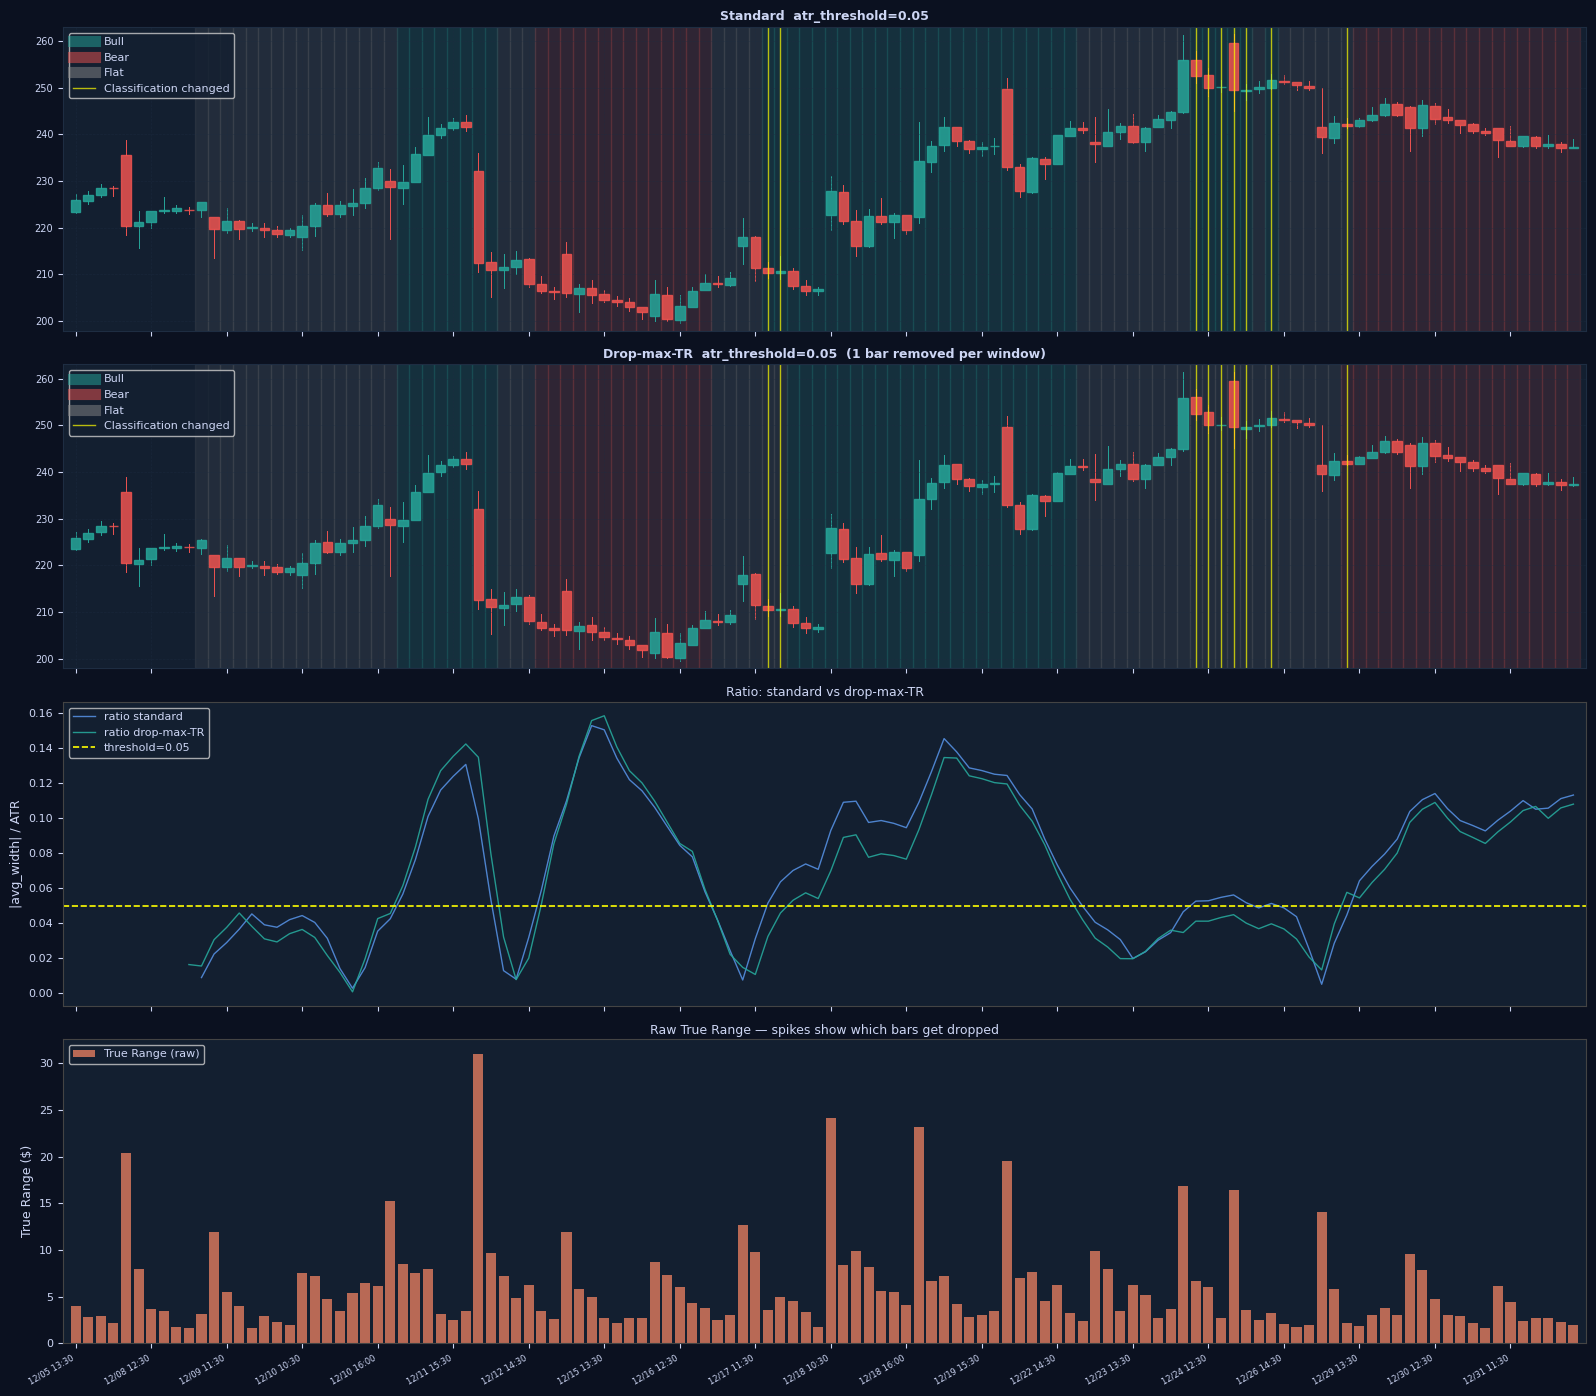

In [21]:
# Robust window: drop the single highest-TR bar before computing avg_width / avg_atr.
# Simpler and more predictable than sigma-based trimming.
import numpy as np

FAST, SLOW, WINDOW = 15, 60, 10
ATR_PERIOD = 14
ATR_THR = 0.05

htf_kd = htf_raw.tail(120).reset_index(drop=True)
kd = compute_kd(htf_kd, fast=FAST, slow=SLOW, atr_period=ATR_PERIOD)

# Raw True Range (unsmoothed) -- used to identify the extreme bar in each window
prev_close = htf_kd['close'].shift(1)
tr_raw = pd.concat([
    htf_kd['high'] - htf_kd['low'],
    (htf_kd['high'] - prev_close).abs(),
    (htf_kd['low']  - prev_close).abs(),
], axis=1).max(axis=1)

def drop_max_tr(values, tr, window):
    """Rolling mean after dropping the single highest-TR bar in each window."""
    out = np.full(len(values), np.nan)
    for i in range(window - 1, len(values)):
        sl_v  = values.iloc[i - window + 1 : i + 1]
        sl_tr = tr.iloc[i - window + 1 : i + 1]
        keep  = sl_tr.index != sl_tr.idxmax()
        out[i] = sl_v[keep].mean()
    return pd.Series(out, index=values.index)

# Standard vs drop-max avg_width and avg_atr
avg_w_std  = kd['width'].rolling(WINDOW).mean()
avg_w_drop = drop_max_tr(kd['width'], tr_raw, WINDOW)

avg_atr_std  = kd['atr'].rolling(WINDOW).mean()
avg_atr_drop = drop_max_tr(kd['atr'], tr_raw, WINDOW)

ratio_std  = (avg_w_std.abs()  / avg_atr_std ).replace([np.inf, -np.inf], np.nan)
ratio_drop = (avg_w_drop.abs() / avg_atr_drop).replace([np.inf, -np.inf], np.nan)

changed = (
    ((ratio_std >= ATR_THR) & (ratio_drop < ATR_THR)) |
    ((ratio_std <  ATR_THR) & (ratio_drop >= ATR_THR))
).fillna(False)
print(f'Bars where classification flips: {changed.sum()} / {(~ratio_std.isna()).sum()}')

# How much the ratio shifts on average
delta = (ratio_drop - ratio_std).dropna()
print(f'Ratio delta:  mean={delta.mean():+.4f}  std={delta.std():.4f}'
      f'  min={delta.min():+.4f}  max={delta.max():+.4f}')

# ── Four-panel chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

# Panels 0-1: trend zones
for ax, use_drop, title in [
    (axes[0], False, f'Standard  atr_threshold={ATR_THR}'),
    (axes[1], True,  f'Drop-max-TR  atr_threshold={ATR_THR}  (1 bar removed per window)'),
]:
    draw_candles(ax, htf_kd)
    r = ratio_drop if use_drop else ratio_std
    w = avg_w_drop if use_drop else avg_w_std
    for i in range(WINDOW, len(htf_kd)):
        ri, wi = r.iloc[i], w.iloc[i]
        if pd.isna(wi):
            continue
        if pd.isna(ri) or ri < ATR_THR:
            color = '#888888'
        elif wi > 0:
            color = GREEN
        else:
            color = RED
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=color, zorder=0)
    for i in changed[changed].index:
        ax.axvline(i, color='yellow', lw=1.0, alpha=0.7, zorder=2)
    ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
    ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
    ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')
    ax.plot([], [], color='yellow',  alpha=0.7, lw=1, label='Classification changed')
    ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
    style_ax(ax, title)

# Panel 2: ratio comparison
ax = axes[2]
ax.set_facecolor(BG2)
ax.plot(ratio_std.index,  ratio_std.values,  color='#5c9cf5', lw=1.0, alpha=0.8,
        label='ratio standard')
ax.plot(ratio_drop.index, ratio_drop.values, color=GREEN,     lw=1.0, alpha=0.9,
        label='ratio drop-max-TR')
ax.axhline(ATR_THR, color='yellow', lw=1.2, ls='--', label=f'threshold={ATR_THR}')
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
ax.set_ylabel('|avg_width| / ATR', color=FG, fontsize=9)
ax.tick_params(colors=FG)
for sp in ax.spines.values(): sp.set_color('#444')
ax.set_title('Ratio: standard vs drop-max-TR', color=FG, fontsize=9, pad=4)

# Panel 3: raw TR per bar (shows which bars would be dropped in their window)
ax = axes[3]
ax.set_facecolor(BG2)
ax.bar(tr_raw.index, tr_raw.values, color='#ff8a65', alpha=0.7, width=0.8,
       label='True Range (raw)')
ax.set_ylabel('True Range ($)', color=FG, fontsize=9)
ax.tick_params(colors=FG)
for sp in ax.spines.values(): sp.set_color('#444')
ax.set_title('Raw True Range — spikes show which bars get dropped',
             color=FG, fontsize=9, pad=4)
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)

step = max(1, len(htf_kd) // 20)
time_ticks(axes[-1], htf_kd, step=step, fmt='%m/%d %H:%M')
plt.tight_layout()
plt.show()


### Adaptive Segments: Split at Zero Crossings of Width

**Problem with fixed window:** when a window spans a reversal, the positive and negative
widths cancel out, blurring the classification.

**Insight:** `width` = d(spread)/dt. Its zero crossings are the natural extrema of the
spread curve — the boundary between a bull phase and a bear phase.

**Approach:**
1. Lightly smooth `width` (rolling-3) to suppress single-bar noise.
2. Find sign-change points of the smoothed width — these are the segment boundaries.
3. For each bar, compute `avg_width` and `avg_ATR` from the **segment start** to that bar
   (causal — no look-ahead).
4. Apply ATR-normalised threshold as before.

This way each segment is coherent in direction; no cross-phase averaging.


Total segments: 11
 seg  start_bar                time_key   len     avg_w  direction
    0  bar=  0  2025-12-05 13:30:00     n=  1  avg_w=+nan  flat
    1  bar=  1  2025-12-05 14:30:00     n=  4  avg_w=+0.1752  flat
    2  bar=  5  2025-12-08 11:30:00     n= 15  avg_w=-0.2016  flat
    3  bar= 20  2025-12-10 12:30:00     n= 13  avg_w=+0.5713  bull
    4  bar= 33  2025-12-12 11:30:00     n= 17  avg_w=-0.8784  bear
    5  bar= 50  2025-12-16 14:30:00     n=  9  avg_w=+0.4089  bull
    6  bar= 59  2025-12-17 16:00:00     n=  1  avg_w=-0.0040  flat
    7  bar= 60  2025-12-18 10:30:00     n= 17  avg_w=+0.8836  bull
    8  bar= 77  2025-12-22 13:30:00     n=  2  avg_w=-0.1225  flat
    9  bar= 79  2025-12-22 15:30:00     n= 16  avg_w=+0.3182  flat
   10  bar= 95  2025-12-26 13:30:00     n= 25  avg_w=-0.4366  bear


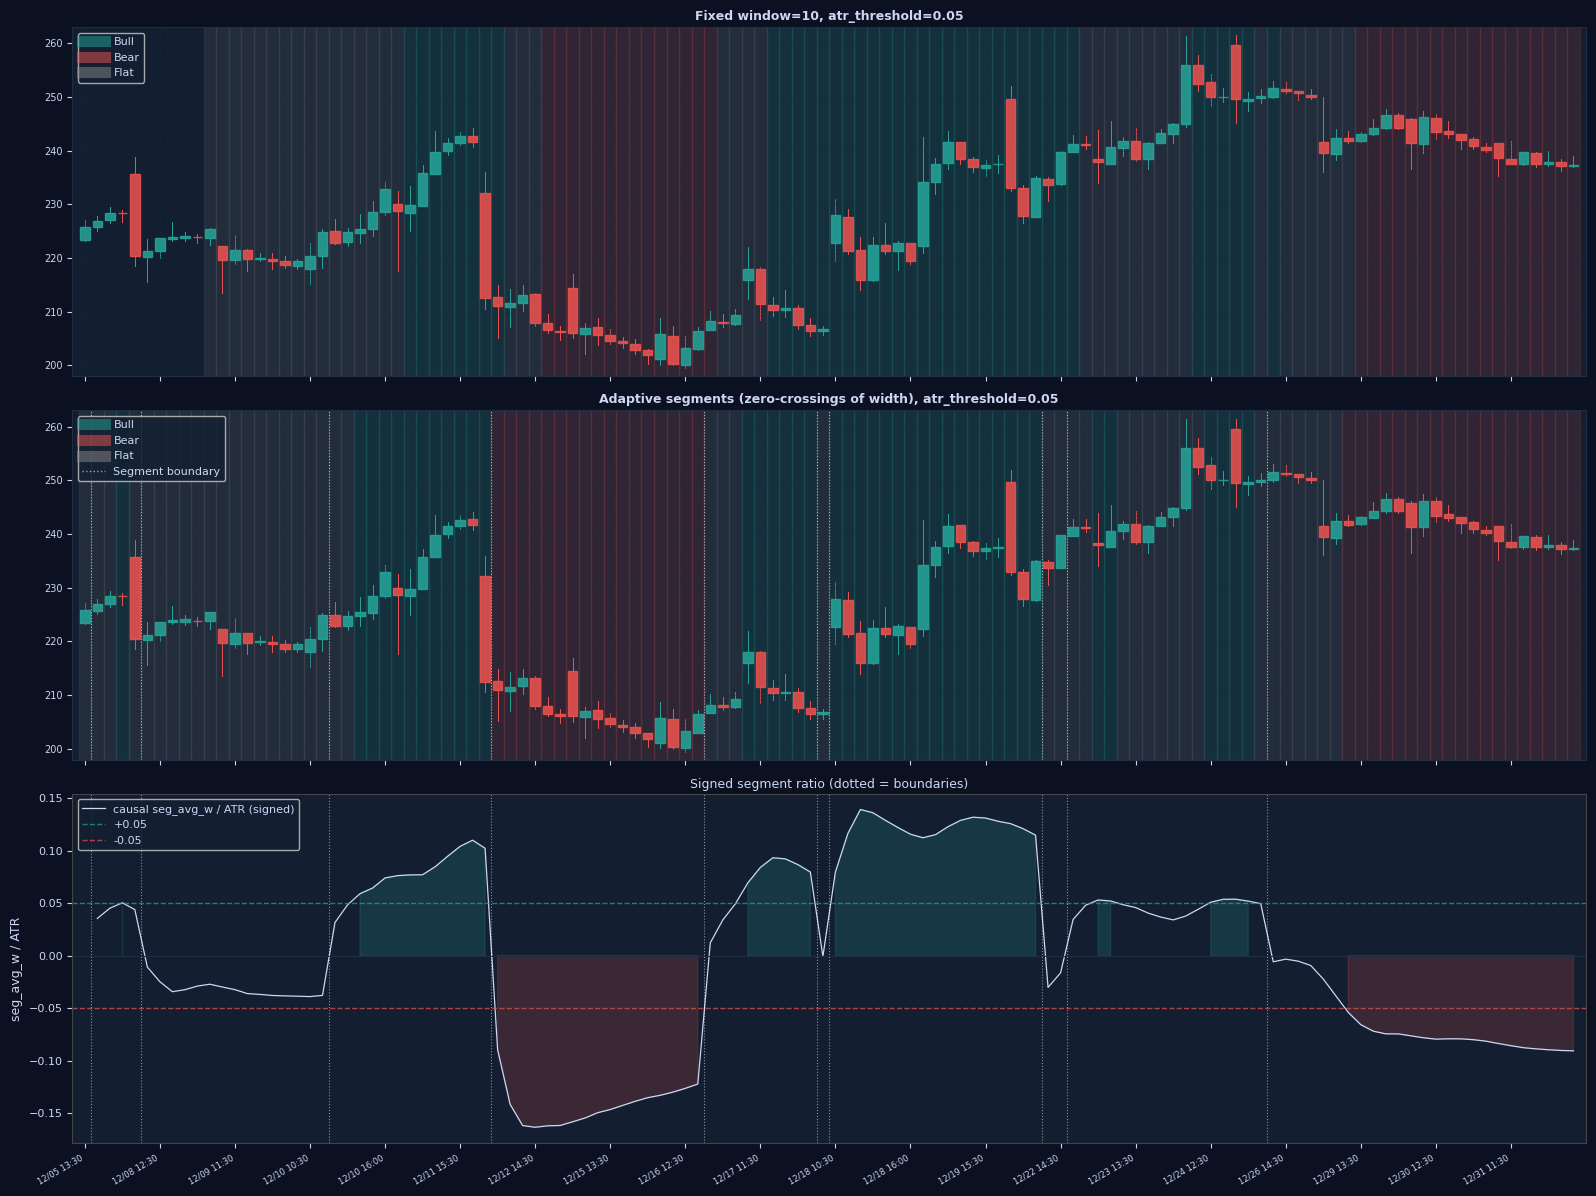

In [22]:
import numpy as np

FAST, SLOW = 15, 60
ATR_PERIOD = 14
ATR_THR    = 0.05
SMOOTH     = 3     # light pre-smoothing to suppress single-bar noise

htf_kd = htf_raw.tail(120).reset_index(drop=True)
kd = compute_kd(htf_kd, fast=FAST, slow=SLOW, atr_period=ATR_PERIOD)

smooth_w = kd['width'].rolling(SMOOTH, min_periods=1).mean()

# --- Segment labels: increment at every sign change of smooth_w ---------------
signs  = np.sign(smooth_w.fillna(0))
change = (signs != signs.shift(1).fillna(signs.iloc[0])).astype(int)
seg_id = change.cumsum()   # integer segment index, same for all bars in a segment

# --- Causal segment stats: mean from segment-start up to each bar i ----------
# Use expanding mean within each segment (no look-ahead).
seg_avg_w   = smooth_w.groupby(seg_id).transform(lambda s: s.expanding().mean())
seg_avg_atr = kd['atr'].groupby(seg_id).transform(lambda s: s.expanding().mean())
seg_ratio   = (seg_avg_w.abs() / seg_avg_atr).replace([np.inf, -np.inf], np.nan)

# Segment length up to bar i (how many bars since last zero crossing)
seg_len = seg_id.groupby(seg_id).transform(lambda s: pd.Series(
    range(1, len(s) + 1), index=s.index))

# Classification
trend_seg = pd.Series('flat', index=kd.index)
bull_mask  = (seg_ratio >= ATR_THR) & (seg_avg_w > 0)
bear_mask  = (seg_ratio >= ATR_THR) & (seg_avg_w < 0)
trend_seg[bull_mask] = 'bull'
trend_seg[bear_mask] = 'bear'

# Print segment table
print(f'Total segments: {seg_id.max() + 1}')
print(f'{"seg":>4}  {"start_bar":>9}  {"time_key":>22}  {"len":>4}  '
      f'{"avg_w":>8}  {"direction"}')
for sid in range(seg_id.max() + 1):
    mask  = seg_id == sid
    idx0  = mask[mask].index[0]
    n     = mask.sum()
    aw    = smooth_w[mask].mean()
    ar    = kd['atr'][mask].mean()
    ratio = abs(aw) / ar if ar > 0 else 0
    dirn  = ('bull' if aw > 0 else 'bear') if ratio >= ATR_THR else 'flat'
    print(f'  {sid:3d}  bar={idx0:3d}  {str(htf_kd.loc[idx0,"time_key"]):22s}'
          f'  n={n:3d}  avg_w={aw:+.4f}  {dirn}')

# --- Comparison chart --------------------------------------------------------
avg_w_fix = kd['width'].rolling(10).mean()
avg_atr_fix = kd['atr'].rolling(10).mean()
ratio_fix = (avg_w_fix.abs() / avg_atr_fix).replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

COLOR = {GREEN: GREEN, 'bull': GREEN, 'bear': RED, 'flat': '#888888'}

# Panel 0: fixed window (10 bars)
ax = axes[0]
draw_candles(ax, htf_kd)
for i in range(10, len(htf_kd)):
    w, r = avg_w_fix.iloc[i], ratio_fix.iloc[i]
    if pd.isna(w): continue
    c = '#888888' if pd.isna(r) or r < ATR_THR else (GREEN if w > 0 else RED)
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=c, zorder=0)
ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
style_ax(ax, f'Fixed window=10, atr_threshold={ATR_THR}')

# Panel 1: adaptive segments
ax = axes[1]
draw_candles(ax, htf_kd)
boundary_xs = []
for i in range(len(htf_kd)):
    t = trend_seg.iloc[i]
    c = GREEN if t == 'bull' else (RED if t == 'bear' else '#888888')
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=c, zorder=0)
    if i > 0 and seg_id.iloc[i] != seg_id.iloc[i-1]:
        boundary_xs.append(i - 0.5)
for x in boundary_xs:
    ax.axvline(x, color='white', lw=0.8, ls=':', alpha=0.6, zorder=2)
ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')
ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')
ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')
ax.plot([], [], color='white',   alpha=0.6, lw=1, ls=':', label='Segment boundary')
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
style_ax(ax, f'Adaptive segments (zero-crossings of width), atr_threshold={ATR_THR}')

# Panel 2: smooth_w signed ratio + segment id shading
ax = axes[2]
ax.set_facecolor(BG2)
signed_ratio = (seg_avg_w / seg_avg_atr).replace([np.inf, -np.inf], np.nan)
ax.plot(signed_ratio.index, signed_ratio.values, color=FG, lw=0.9,
        label='causal seg_avg_w / ATR (signed)')
ax.axhline(0,       color=GRID if 'GRID' in dir() else '#1e2d42', lw=0.8)
ax.axhline( ATR_THR, color=GREEN,  lw=1.0, ls='--', alpha=0.7, label=f'+{ATR_THR}')
ax.axhline(-ATR_THR, color=RED,    lw=1.0, ls='--', alpha=0.7, label=f'-{ATR_THR}')
for x in boundary_xs:
    ax.axvline(x, color='white', lw=0.8, ls=':', alpha=0.5)
ax.fill_between(signed_ratio.index, 0, signed_ratio.values,
                where=signed_ratio >  ATR_THR, color=GREEN, alpha=0.18)
ax.fill_between(signed_ratio.index, 0, signed_ratio.values,
                where=signed_ratio < -ATR_THR, color=RED,   alpha=0.18)
ax.legend(loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
ax.set_ylabel('seg_avg_w / ATR', color=FG, fontsize=9)
ax.tick_params(colors=FG)
for sp in ax.spines.values(): sp.set_color('#444')
ax.set_title('Signed segment ratio (dotted = boundaries)', color=FG, fontsize=9, pad=4)

step = max(1, len(htf_kd) // 20)
time_ticks(axes[-1], htf_kd, step=step, fmt='%m/%d %H:%M')
plt.tight_layout()
plt.show()


### Conditional Lag Compensation

Unconditionally shifting every boundary one bar earlier over-corrects.
The right rule: only move bar `i-1` into the new segment if doing so
**strengthens** that segment.

**Conditions to shift bar `i-1` into the new segment starting at bar `i`:**
1. New segment is **not flat** (`|smooth_w[i]| / ATR[i] >= atr_threshold`)
2. Raw `width[i-1]` has the **same sign** as the new segment's direction --
   meaning the actual reversal already started at `i-1`, the smoothed zero
   crossing is just one bar late due to smoothing lag

If the new segment is flat, or bar `i-1` would pull the average the wrong
way, the boundary stays at bar `i`.


Segments (original): 11  ->  (conditional + min=3): 8
Bars reclassified vs original: 6 / 120

 seg  start                time_key    n     avg_w  direction
    0     0  2025-12-05 13:30:00       5  +0.1752  flat
    1     5  2025-12-08 11:30:00      15  -0.2016  flat
    2    20  2025-12-10 12:30:00      12  +0.5919  bull
    3    32  2025-12-12 10:30:00      18  -0.8116  bear
    4    50  2025-12-16 14:30:00      10  +0.3676  bull
    5    60  2025-12-18 10:30:00      19  +0.7777  bull
    6    79  2025-12-22 15:30:00      16  +0.3182  flat
    7    95  2025-12-26 13:30:00      25  -0.4366  bear


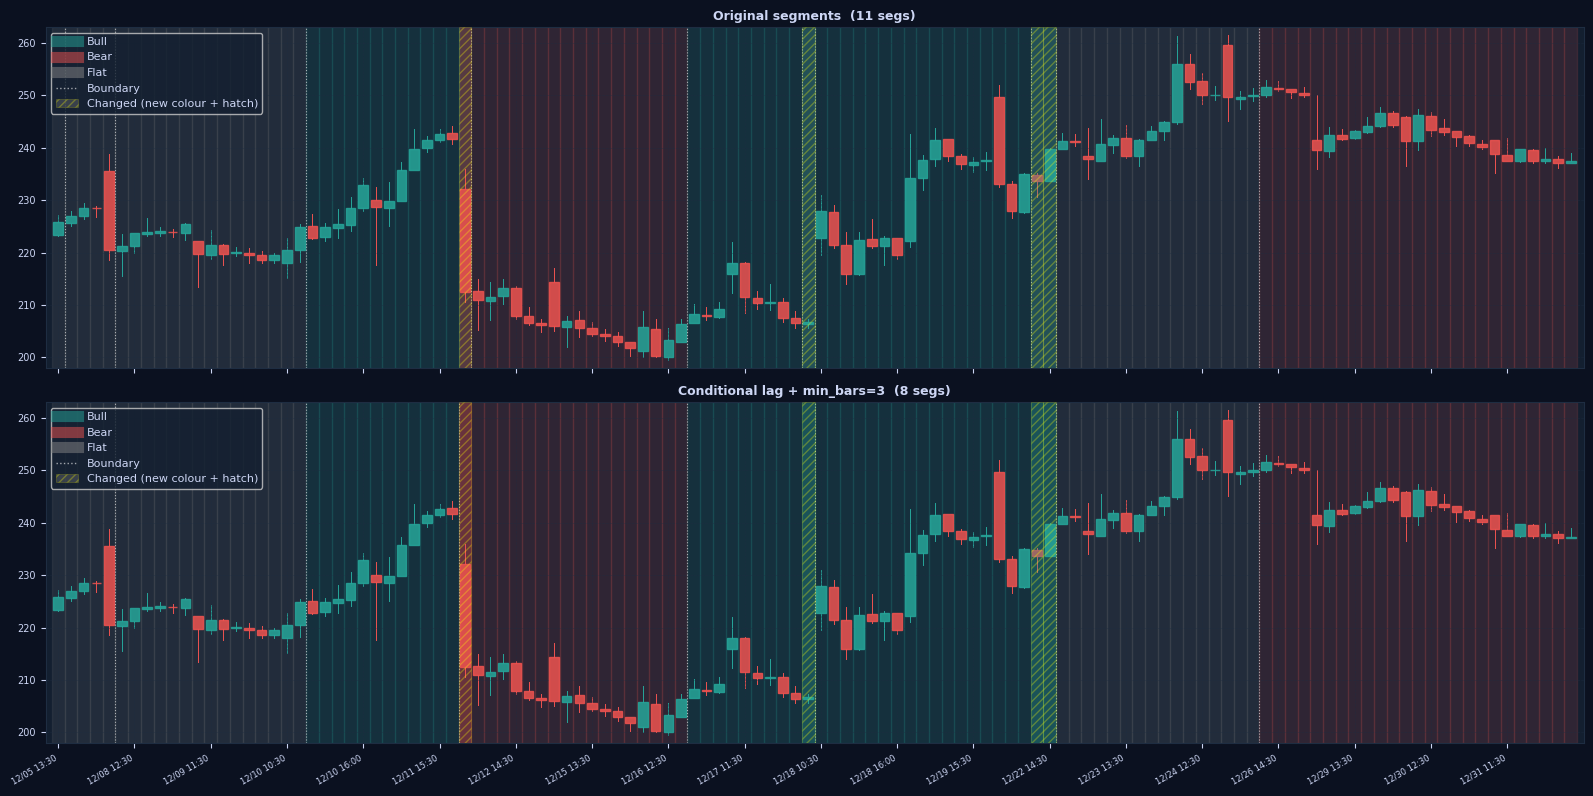

In [23]:
def conditional_lag_segments(smooth_w, raw_w, atr, atr_thr, min_bars=3):
    """Segment by zero-crossings of smooth_w with conditional boundary shift
    and minimum segment length enforcement.

    At each crossing (bar i):
      - Shift boundary to i-1 if new segment is not flat AND raw_w[i-1]
        already points in the new direction.
    Post-processing:
      - Any segment shorter than min_bars is merged into the previous segment
        (or forward into the next segment if it is the first one).
    """
    n      = len(smooth_w)
    signs  = np.sign(smooth_w.fillna(0))
    raw_v  = raw_w.values
    atr_v  = atr.values
    sw_v   = smooth_w.values

    # ── Pass 1: build boundaries with conditional lag shift ───────────────────
    boundaries = [0]
    for i in range(1, n):
        prev_s, curr_s = signs.iloc[i-1], signs.iloc[i]
        if curr_s == 0 or prev_s == 0 or curr_s == prev_s:
            continue
        new_dir = curr_s
        flat = (atr_v[i] > 0 and abs(sw_v[i]) / atr_v[i] < atr_thr)
        if flat:
            boundaries.append(i)
        elif np.sign(raw_v[i-1]) == new_dir:
            boundaries.append(i - 1)
        else:
            boundaries.append(i)

    # ── Pass 2: merge segments shorter than min_bars ──────────────────────────
    # First segment: merge forward if too short (no previous to absorb it).
    if len(boundaries) > 1 and boundaries[1] - boundaries[0] < min_bars:
        boundaries.pop(1)

    # Remaining segments: merge backward into previous.
    i = 1
    while i < len(boundaries):
        end = boundaries[i + 1] if i + 1 < len(boundaries) else n
        if end - boundaries[i] < min_bars:
            boundaries.pop(i)   # remove start of short segment; don't advance i
        else:
            i += 1

    # ── Build seg_id ──────────────────────────────────────────────────────────
    seg_arr = np.zeros(n, dtype=int)
    for seg, start in enumerate(boundaries):
        end = boundaries[seg + 1] if seg + 1 < len(boundaries) else n
        seg_arr[start:end] = seg

    return pd.Series(seg_arr, index=smooth_w.index)


MIN_BARS = 3
seg_id_cond = conditional_lag_segments(
    smooth_w, kd['width'], kd['atr'], ATR_THR, min_bars=MIN_BARS)

seg_avg_w_cond   = smooth_w.groupby(seg_id_cond).transform(
    lambda s: s.expanding().mean())
seg_avg_atr_cond = kd['atr'].groupby(seg_id_cond).transform(
    lambda s: s.expanding().mean())
seg_ratio_cond   = (seg_avg_w_cond.abs() / seg_avg_atr_cond).replace(
    [np.inf, -np.inf], np.nan)

trend_cond = pd.Series('flat', index=kd.index)
trend_cond[(seg_ratio_cond >= ATR_THR) & (seg_avg_w_cond > 0)] = 'bull'
trend_cond[(seg_ratio_cond >= ATR_THR) & (seg_avg_w_cond < 0)] = 'bear'

# Visualisation colour: use full-segment mean so every bar in a segment
# gets the same colour.  Algorithm (trend_cond) stays causal.
def seg_viz_direction(sid_series, smooth_w, atr, atr_thr):
    mapping = {}
    for sid in range(sid_series.max() + 1):
        mask = sid_series == sid
        aw = smooth_w[mask].mean()
        ar = atr[mask].mean()
        r  = abs(aw) / ar if ar > 0 else 0
        if r >= atr_thr:
            mapping[sid] = 'bull' if aw > 0 else 'bear'
        else:
            mapping[sid] = 'flat'
    return sid_series.map(mapping)

trend_orig_viz = seg_viz_direction(seg_id,      smooth_w, kd['atr'], ATR_THR)
trend_cond_viz = seg_viz_direction(seg_id_cond, smooth_w, kd['atr'], ATR_THR)

def boundary_xs(sid):
    return [i - 0.5 for i in range(1, len(sid)) if sid.iloc[i] != sid.iloc[i-1]]

bx_orig = boundary_xs(seg_id)
bx_cond = boundary_xs(seg_id_cond)

diff = (trend_seg != trend_cond).sum()
print(f'Segments (original): {seg_id.max() + 1}  ->  (conditional + min={MIN_BARS}): {seg_id_cond.max() + 1}')
print(f'Bars reclassified vs original: {diff} / {len(kd)}')
print()
print(f'{"seg":>4}  {"start":>4}  {"time_key":>22}  {"n":>3}  {"avg_w":>8}  direction')
for sid in range(seg_id_cond.max() + 1):
    mask = seg_id_cond == sid
    idx0 = mask[mask].index[0]
    n_   = mask.sum()
    aw   = smooth_w[mask].mean()
    ar   = kd['atr'][mask].mean()
    r    = abs(aw) / ar if ar > 0 else 0
    dirn = ('bull' if aw > 0 else 'bear') if r >= ATR_THR else 'flat'
    print(f'  {sid:3d}  {idx0:4d}  {str(htf_kd.loc[idx0,"time_key"]):22s}'
          f'  {n_:3d}  {aw:+.4f}  {dirn}')

# ── Comparison chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor=BG, sharex=True)
fig.subplots_adjust(hspace=0.08)

for ax, trend_viz, trend_alg, bx, title in [
    (axes[0], trend_orig_viz, trend_seg,  bx_orig,
     f'Original segments  ({seg_id.max()+1} segs)'),
    (axes[1], trend_cond_viz, trend_cond, bx_cond,
     f'Conditional lag + min_bars={MIN_BARS}  ({seg_id_cond.max()+1} segs)'),
]:
    draw_candles(ax, htf_kd)
    for i in range(len(htf_kd)):
        t = trend_viz.iloc[i]
        c = GREEN if t == 'bull' else (RED if t == 'bear' else '#888888')
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.13, color=c, zorder=0)
    for x in bx:
        ax.axvline(x, color='white', lw=0.8, ls=':', alpha=0.6, zorder=2)
    for i in range(len(htf_kd)):
        if trend_orig_viz.iloc[i] != trend_cond_viz.iloc[i]:
            t = trend_cond_viz.iloc[i]
            new_c = GREEN if t == 'bull' else (RED if t == 'bear' else '#888888')
            ax.axvspan(i - 0.5, i + 0.5, facecolor=new_c, alpha=0.30,
                       hatch='////', edgecolor='yellow', linewidth=0.4,
                       zorder=3)
    import matplotlib.patches as mpatches
    h_bull = ax.plot([], [], color=GREEN,     alpha=0.5, lw=8, label='Bull')[0]
    h_bear = ax.plot([], [], color=RED,       alpha=0.5, lw=8, label='Bear')[0]
    h_flat = ax.plot([], [], color='#888888', alpha=0.5, lw=8, label='Flat')[0]
    h_bnd  = ax.plot([], [], color='white',   lw=1, ls=':', alpha=0.6, label='Boundary')[0]
    h_chg  = mpatches.Patch(facecolor='#888888', alpha=0.3, hatch='////',
                             edgecolor='yellow', linewidth=0.4,
                             label='Changed (new colour + hatch)')
    ax.legend(handles=[h_bull, h_bear, h_flat, h_bnd, h_chg],
              loc='upper left', fontsize=8, facecolor=BG2, labelcolor=FG)
    style_ax(ax, title)

step = max(1, len(htf_kd) // 20)
time_ticks(axes[-1], htf_kd, step=step, fmt='%m/%d %H:%M')
plt.tight_layout()
plt.show()


### ATR-Ratio Distribution: Deriving a Data-Driven `atr_threshold`

`atr_threshold=0.05` was an arbitrary starting point. Here we compute
`|seg_avg_width| / seg_avg_ATR` for every historical segment on the full
HTF dataset and examine its distribution to choose a threshold with a
clear semantic (e.g. "filter the weakest 25% of segments").


Segments: 122  (from 1545 HTF bars)
|seg_avg_width| / ATR  percentiles:
  p10=0.020  p25=0.036  p50=0.072  p75=0.101  p90=0.128

Candidate thresholds:
  p25=0.036  -> filter weakest 25% of segments
  p50=0.072  -> filter weakest 50% of segments
  current hardcoded 0.05 sits at ~p40


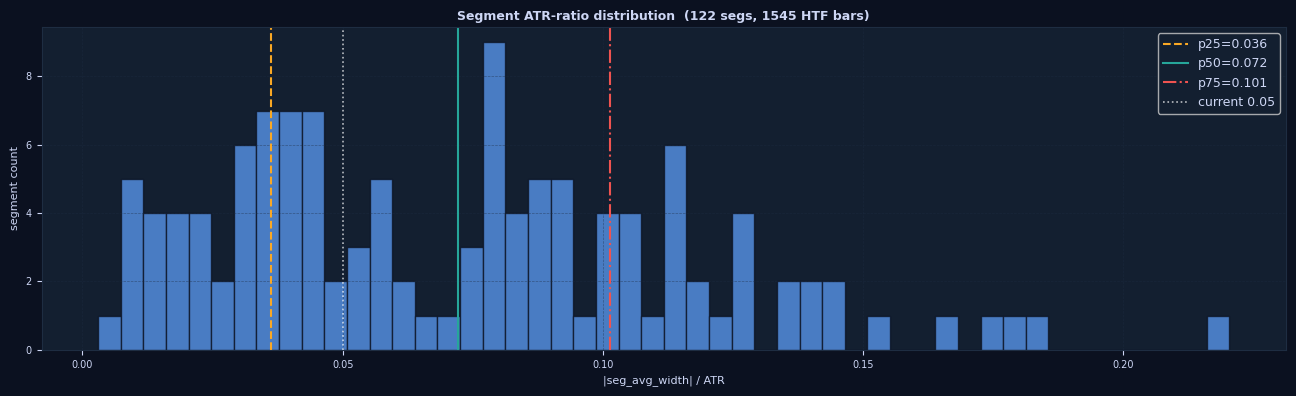

In [24]:
# Run segmentation on the full HTF history (not just the last 120 bars).
# atr_thr=0 during boundary detection so we capture all natural segment
# breaks; we are only analysing the ratio distribution here, not filtering.

htf_full = htf_raw.reset_index(drop=True)
kd_full  = compute_kd(htf_full, fast=FAST, slow=SLOW, atr_period=ATR_PERIOD)
sw_full  = kd_full['width'].rolling(SMOOTH, min_periods=1).mean()

seg_full = conditional_lag_segments(
    sw_full, kd_full['width'], kd_full['atr'],
    atr_thr=0.0, min_bars=MIN_BARS,
)

seg_ratios = []
for sid in range(int(seg_full.max()) + 1):
    mask    = seg_full == sid
    sw_seg  = float(sw_full[mask].mean())
    atr_seg = float(kd_full['atr'][mask].mean())
    if atr_seg > 0 and not np.isnan(sw_seg):
        seg_ratios.append(abs(sw_seg) / atr_seg)

ratios = np.array(seg_ratios)
p10, p25, p50, p75, p90 = np.percentile(ratios, [10, 25, 50, 75, 90])
print(f'Segments: {len(ratios)}  (from {len(htf_full)} HTF bars)')
print(f'|seg_avg_width| / ATR  percentiles:')
print(f'  p10={p10:.3f}  p25={p25:.3f}  p50={p50:.3f}  p75={p75:.3f}  p90={p90:.3f}')
print(f'\nCandidate thresholds:')
print(f'  p25={p25:.3f}  -> filter weakest 25% of segments')
print(f'  p50={p50:.3f}  -> filter weakest 50% of segments')
pct_of_005 = int((ratios < 0.05).mean() * 100)
print(f'  current hardcoded 0.05 sits at ~p{pct_of_005}')

# ---- Histogram -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4), facecolor=BG)
ax.hist(ratios, bins=50, color='#5c9cf5', alpha=0.75, edgecolor=BG)
for pct, val, col, ls in [
    (25, p25, GOLD, '--'),
    (50, p50, GREEN, '-'),
    (75, p75, RED,   '-.'),
]:
    ax.axvline(val, color=col, lw=1.5, linestyle=ls, label=f'p{pct}={val:.3f}')
ax.axvline(0.05, color='white', lw=1.2, linestyle=':', alpha=0.7, label='current 0.05')
ax.set_xlabel('|seg_avg_width| / ATR', color=FG)
ax.set_ylabel('segment count', color=FG)
ax.tick_params(colors=FG)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.set_facecolor(BG2)
ax.legend(fontsize=9, facecolor=BG2, labelcolor=FG)
style_ax(ax, f'Segment ATR-ratio distribution  ({len(ratios)} segs, {len(htf_full)} HTF bars)')
plt.tight_layout()
plt.show()
